In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
from scipy.stats import norm

from pykat import finesse
from pykat.detectors import *
from pykat.components import *
from pykat.commands import *
from pykat.structs import *
from pykat.tools.plotting.beamtrace import plot_beam_trace


# Introduction
The aim of this work is to see if there is a difference in the beam transmitted through the SRM during a single bounce measurement, which is effectively a reflection from the ITM, and a measurement when the light is resonant in the arm cavities. In particular, we want to know how a RoC error in SR3 changes the beam size in both the single bounce and locked arm cases.

We expect there to be a difference between the single bounce and locked arm beam shape since the arms are high finesse and the SRC is low finesse. It was found that the only significant difference between the two measurements in terms of the amount of HOM relative to TM00 was around where the HG20+02 modes are resonant in the SRC. The case with a locked arm reduces the amount of HG20+02 mode compared to just the SRC. The simulation did not seem to be limited by `maxtem` (which was set to 6), all though I am unsure if I believe the true depths of the dips in the HOM plots.
# Optical Components
The following table gives the optical properties of each optic relevent to finding the mode at the SRM.

|Optic|RoC (m)|Focal Length (m)| Reference |
|---|---|---|---|
| SRM | -5.6938 | -2.8469 | [T0900043](https://dcc.ligo.org/LIGO-T0900043/public) |
| SRM-02 | -5.673 ± 0.002 | -2.8365 ± 0.001 |  [galaxy page](https://galaxy.ligo.caltech.edu/optics/)|
| SR2 | -6.427 | -3.2135 | [T0900043](https://dcc.ligo.org/LIGO-T0900043/public)|
| SR2-04 | -6.406 ± 0.006 | -3.203 ± 0.003 | [T1300653](https://dcc.ligo.org/LIGO-T1300653) and [galaxy page](https://galaxy.ligo.caltech.edu/optics/)|
| SR3 | 36 | 18 | [T0900043](https://dcc.ligo.org/LIGO-T0900043/public)|
| SR3-01 | 35.97 ± 0.012 | 17.985 ± 0.006 |[E1101231](https://dcc.ligo.org/E1101231-v1) and [galaxy page](https://galaxy.ligo.caltech.edu/optics/)|
| ITM (Vacuum Side) | 1934 | 967.0 |[T0900043](https://dcc.ligo.org/LIGO-T0900043/public) | 
| ITM-08 (Vacuum Side) (Y arm) | 1938.44 | 969.22 |[galaxy page](https://galaxy.ligo.caltech.edu/optics/)| 
| ITM (FS Side) | 1334 | 667 | - |
| ITM-08 (FS Side) (Y arm) | 1336.86 | 668.43 | - |
| ETM (Vacuum Side) | 2245 | 1122.5 |[T0900043](https://dcc.ligo.org/LIGO-T0900043/public) | 
| ETM-15 (Vacuum Side) (Y arm) | 2245.4 | 1122.7 |[galaxy page](https://galaxy.ligo.caltech.edu/optics/)| 

ITM transmission = 1.48%. SRM tranmission = 32.4%

|Optic| AOI (degrees) |
|---|---|
|SR3 | 0.608 |
|SR2 | 0.748 |

# Spacings
The nominal values with a diagram can be found in [D0902838](https://dcc.ligo.org/LIGO-D0902838) for the H1/L1 spacings. This information is also in  [T0900043](https://dcc.ligo.org/LIGO-T0900043/public). The L1 Zeemax layout is found in [D0902216](https://dcc.ligo.org/LIGO-D0902216). The first table is from the Zeemax coordinates (with the inclusion of thick optics). Most spacings do not require sub mm accuracy, however SR3 to SR2 does since the rayleigh range of this beam is very small (about 4cm).

| Space Name | Length (m)|
|---|---|
| ETMY to ITMY| 3994.4850|
| ITMY to CP| 0.02|
| CP to BS HR| 4.8471|
|BS AR to SR3| 19.3659|
|SR3 to SR2| 15.4435|
|SR2 to SRM| 15.7562|

The second table is the design specification

| Space Name | Length (m)|
|---|---|
| ETMY to ITMY| 3994.5|
| ITMY to CP| 0.005|
| CP to BS HR| 4.8497|
|BS AR to SR3| 19.368|
|SR3 to SR2| 15.4607|
|SR2 to SRM| 15.726|

The Finesse File found in [T1300901](https://dcc.ligo.org/LIGO-T1300901) uses

| Space Name | Length (m)|
|---|---|
| ETMY to ITMY| 3994.515|
| ITMY to CP| 0.02 |
| CP to BS HR| 4.847|
|BS AR to SR3| 19.3661|
|SR3 to SR2| 15.4435|
|SR2 to SRM| 15.7566|

ITM thickness = 0.200 m. CP thickness = 0.100m. BS thickness = 0.0685 m, with the angle of incidence, this becomes 0.1202 m

# Model Descriptions

## Finesse Manual Notes

Mode mismatch is caused beams and cavities with differing waist size and position interacting with each other (e.g. by intereference or by entering a cavity). Using the paraxial approximation, a beam/ cavity can be mathematically described using a basis set of HG modes. If there is only one beam, then it makes sense to describe the beam using just one HG00 mode, rather than a combination of HG modes (which you could do). However, when a beam is interacting with a cavity, the beam may be misaligned or not mode matched correctly. Within the paraxial approximation, this can be modelled as ac coupling coefficient between one mode to another. If this is the case, the choice of basis set is not as obvious as it was for a beam that never interacts with another beam or cavity. Small mode mismatches can be described as a coupling between the HG00 mode and the HG20+02 mode.

Finesse lets you set the microscopic tunings of each mirror, not the phase of the light fields (which is considered an output). For ease of use, finesse makes some 'simplifications'. It sets the length of spaces to be an integer multiple of wavelengths, meaning that cavities are resonant by default. The microscopic positions can be 'tuned' in degrees.

Finesse applies the effect of gouy phase to each HOM as a phase shift.

- `cav ` and `gauss `: ` cav ` computes the eigenmode of a stable cavity defined by start and end nodes. `gauss` sets the beam parameter at 1 nodes, whereas `cav` does it for all nodes in a cavity. If two cavities are defined in a simulation, the latter `cav` command overwrites the beam parameter set by the previous `cav` command. `gauss ` is executed after the cavities have been set.

- ` start node `: Sets the starting position of the beam trace algorithm, which must be a node within a cavity or must be set explicitly with the gauss command. This won't actually effect the outcome of the simulation (I think).

- ` phase `: Should set to 2.

Finesse defines the proper beam parameter for each segment i.e. the eigenmode for each cavity is defined and the beam at each gauss command is defined, and the trace algorithm works out the beam parameter at all other nodes. Each optical component transforms the basis set of HG modes in the same way so the modes are not coupled. The relative power in each mode stays the same. 

A coupling between the HG modes happens whenever a beam described by $q_1$ enters a segment described by $q_2$. This could happen between two mismatched cavities, or a mismatched laser and cavity. These coupling coefficents are analytically derived by [Bayer-Helms](https://doi.org/10.1364/AO.23.001369). This means that when 
#### note about the beam trace algorithm
Once the beam parameter has been defined

This algorithm starts calculating the beam at either the node defined by startnode (which must be a node in a cavity), or the input to the first cavity/gaussian beam command. Without defining a cavity or a gaussian beam, Finesse uses the default beam parameter (2mm waist at the laser).

The beam is then calculated at each successive node. At every component, the transformation by the ABCD matrix decribing th component is applied to the beam parameter. At a beamsplitter, each path is followed one after antoher. The paths end at an already encountered node, or a dump.

If a node is found that already has a beam parameter defined at it i.e. defined by the gauss command or cav, then the beam parameter in the trace algorithm is changed to the defined node.
#### Paraxial Approximation
The parameter $\kappa$,
$$
\kappa = \left(\frac{w_0}{2z_R}\right)^2 = \left(\frac{\lambda}{2\pi w_0}\right)^2
$$
can be used to determine whether a beam will behave, to first order, in a way which can be modelled by HG modes. If $\kappa \ll 1 $ then the paraxial approximation is valid, with the error being of the order $\kappa^2$. This can be translated into a couple of simple rules

- The angle of divergence should be less that 35 degrees.
- The difference in waist size should not be more than a factor of $\sqrt{10}$.

The modelling that will be done satisfies this approxiamtion. It is assumed that the beams have okay modematching. The largest angle of divergence is between SR3 and SR2, and this is well below 35 degrees (~0.2degrees between SR2 and SR3).

## Description of modelling
The simulation starts with a laser. The beam parameter at the laser should be defined so that there is no difference between the single bounce and the locked arm simulation. To define the beam parameter, I use the `gauss` command. In this simulation, to mode matching from the laser to the arm cavities should be  perfect (actual amount is 99.99999%). See appendix A for details on how w0 and z were determined for the `gauss` command used on the laser.

`cav` commands where used to set up the arm cavities and the SRC. Without these, the simulation may not produce realisitc results.

The detectors used to analyse the mode-matching between the nominal arm mode (which matches the laser mode) and the SRC mode are `pd`. To detect the total amount of light, no mask is applied. To detect the amount of higher order light a `mask [pd] 0 0 0` command is used. This sets the sensitivity of the photodiode to the HG00 mode to 0. The mode matching is then determined as 1-HOM/total light.

All simulations use the same spacings, RoC and focal lengths, apart from the focal length of SR3 which is changed throughout the simulations. These lengths in the SRC are ones directly obtained from the zeemax model of the LLO interferometer. To simplify the modelling, the SRC telescope is constructed using `lens` rather than `bs` with `atrr` commands (although its not much more complex to use `bs`). The focal lengths in the SRC are the measured values for the LLO optics. The arms are both made to be identical for simplicity, and are based off the nominal design. A 50km thermal lens is assumed in the calculation.

To set up the SRC `cav` command, the cavity was defined as being between the HR surface of the SRM and the HR surface ITMy.

I'm not sure if tunings actually matter in this simulation, since the eigenmodes of the cavities still exist even if perfect destructive interference happens and there is no beam, but since I wanted some light in the dark port, I set the tuning of the beam splitter. However, this isn't the way the dark fringe offset is set in reality.

The tracing algorithm will be started from `n1`, since this is defined by a gauss command.

`maxtem` is set to 6

### Diagram of Simulation
![Simulation](diagram_of_sim2.png)

## Analysis
The two optimum mode matching solutions seems a bit weird, but I think it is explained in the paper [Design of the Advanced LIGO recycling cavities](https://doi.org/10.1364/OE.16.010018). There is no difference in the amount of suppression of the HOM apart from around 45deg gouy phase where the HG20+02 modes will be resonant. 

# Arm and SRC

The following block contains the *base* code for all the simulations. It contains:
- A laser that is mode matched to the arms cavities
- a thick beamsplitter (with width 1pm). The thick beamsplitter fixes any phase problems.
- ETM and ITM have 10ppm loss
- 50km thermal lens in ITM
- signal recycling cavity with thick SRM

A sanity check simulation is run which gives the beam parameters at several points in the IFO to check that everything is defined properly e.g. there could be minus sign errors in the RoC for the optics. The profile of the beam that is transmitted through the SRM is plotted.

This simulation is called `michelson_with_FP_arms_and_src`


Removed existing object 'ITMy_refl' of type <class
'pykat.detectors.pykat.detectors.beam_8'> to add line 'beam
ITMy_refl nITMyHRa'

Parsing `mask p_out_hOM 0 0 0` into pykat object not implemented yet, added as extra line.
--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:36:46.738767


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 0.211433 seconds


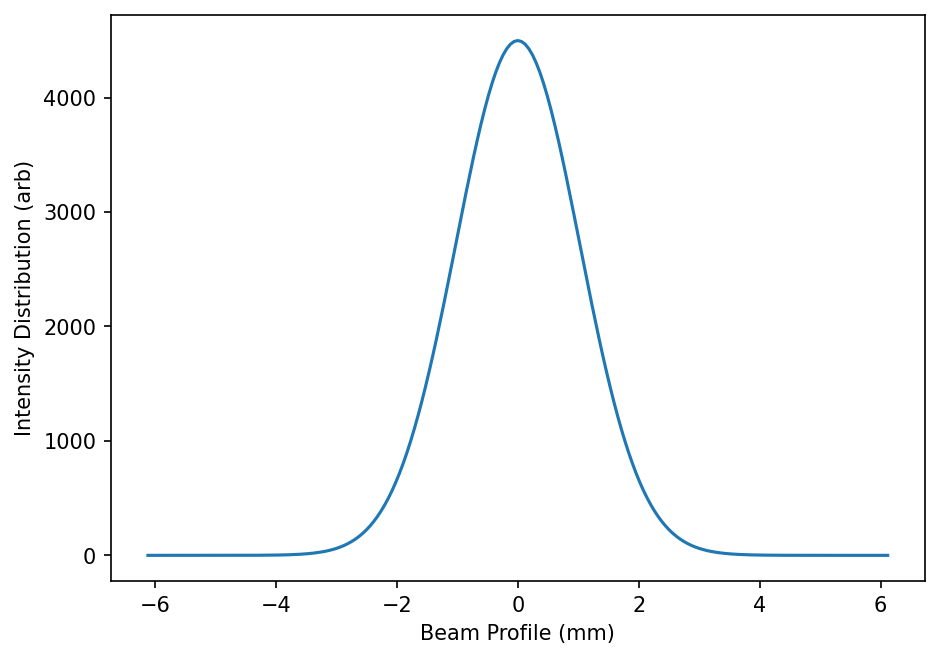

beam width at ITM = 53.0 mm.
beam width at SRM = 2.1 mm.
Power in:  5000000.000000
Power ref:  4973195.541278
Power out:  0.029493
HOM power out:  4.328199e-05
HOM % :  0.146752
Gouy Phase accumulated within SRC = 18.6798330284094


In [3]:
#n.b. doesn't include losses, can be added later.
#n.b. changed thermal lens to 25km
michelson_with_FP_arms_and_src_code = """ 
l l1 5M 0 n1
gauss beamParaml1 l1 n1 0.00864064287177005 -1339.83683935 

maxtem 6

s space1 1 n1 bs_a

#################################################
#bs beam_splitter 0.5 0.5 $phi_BS 0 bs_a bs_b bs_c bs_d

bs BSfront 0.5 0.5 0 0 bs_a bs_b nBSi1 nBSi3
s BSsubstrate1 1p 1.45 nBSi1 nBSi2
s BSsubstrate2 1p 1.45 nBSi3 nBSi4
bs BSback1 0 1 0 0 nBSi2 dump bs_c dump
bs BSback2 0 1 0 0 nBSi4 dump bs_d dump
 
##################################################
## Y ARM

s s_bs_to_ITMy 4.8471 bs_b nITMyARa

#ITMy
m1 ITMyAR 1 0 $phi_ITMy nITMyARa nITMyARb
s sITMy_thickness 0.05 1.45 nITMyARb nITMyTLa
lens ITMyTL 50k nITMyTLa nITMyTLb
s sITMy_thickness2 0.05 1.45 nITMyTLb nITMyHRa
m1 ITMy 0.0148 10u $phi_ITMy nITMyHRa nITMyHRb
attr ITMy Rc -1934

s space_arm_y 3994.5 nITMyHRb nETMy 

m1 ETMy 0 10u $phi_ETMy nETMy dump
attr ETMy Rc 2245

cav army ETMy nETMy ITMy nITMyHRb

##################################################

## X ARM

s s_bs_to_ITMx 4.8471 bs_c nITMxARa

#ITMx
m1 ITMxAR 1 0 $phi_ITMx nITMxARa nITMxARb
s sITMx_thickness 0.05 1.45 nITMxARb nITMxTLa
lens ITMxTL 50k nITMxTLa nITMxTLb
s sITMx_thickness2 0.05 1.45 nITMxTLb nITMxHRa
m1 ITMx 0.0148 10u $phi_ITMx nITMxHRa nITMxHRb
attr ITMx Rc -1934

s space_arm_x 3994.5 nITMxHRb nETMx

m1 ETMx 0 10u $phi_ETMx nETMx dump
attr ETMx Rc 2245

cav armx ETMx nETMx ITMx nITMxHRb

##################################################

## SRC 

s bs_to_SR3 19.3659 bs_d nSR3a

lens SR3 17.985 nSR3a nSR3b  

s SR3_to_SR2 15.4435 nSR3b nSR2a

lens SR2 -3.203 nSR2a nSR2b

s SR2_to_SRM 15.7562 nSR2b nSRMa

m1 SRM 0.324 0 0 nSRMa nSRMb
s SRM_substrate 0.07 1.45 nSRMb nSRMc
m SRM_AR 0 1 0 nSRMc nSRMd
attr SRM Rc -5.673

#cav src ITMx nITMxHRa SRM nSRMa

##################################################
#N.B these tunings don't represent how an IFO is kept on the dark fringe
const phi_ITMx 0 
const phi_ITMy 0
const phi_ETMx 0 
const phi_ETMy 0
const phi_BS 0  
##################################################

beam SRM_trans nSRMd
#mask SRM_trans 0 0 0

bp SRM_trans_w0 x w0 nSRMd
bp SRM_trans_w x w nSRMd
bp SRM_trans_r x r nSRMd

bp laser_w x w0 n1
bp laser_z x z n1

beam ITMy_refl nITMyHRa
beam ITMy_refl nITMyHRa

bp ITMy_refl_w x w nITMyHRa
bp ITMx_refl_w x w nITMxHRa

pd p_in bs_a*
pd p_ref bs_a

pd p_out nSRMd

pd p_out_hOM nSRMd
mask p_out_hOM 0 0 0

ad ad_HOM_2_y 2 0 0 nSRMd
ad ad_HOM_2_x 0 2 0 nSRMd

gouy src_gouy y sITMx_thickness sITMx_thickness2 s_bs_to_ITMx bs_to_SR3 SR3_to_SR2 SR2_to_SRM

trace 64
phase 2

xaxis SRM_trans x lin -10 10 200 
"""
#create a kat object for the ifo with fabry perot cavities
michelson_with_FP_arms_and_src = finesse.kat()
#parse the base code
michelson_with_FP_arms_and_src.parse(michelson_with_FP_arms_and_src_code)

#set detuning for signal recyling mode (srm phi = 0)
michelson_with_FP_arms_and_src.SRM.phi = 0 #89.9989780433498 #ref D0902838

#set ETM detuning for signal recyling mode DC offset (srm phi = 0) 
etm_tuning_sr = 2.76e-6
michelson_with_FP_arms_and_src.ETMy.phi =  -etm_tuning_sr #0.00179545319662242
michelson_with_FP_arms_and_src.ETMx.phi =  etm_tuning_sr #-0.00184678655646107

#run a simulation to check if the beam profile looks correct and plot it
sanity_check = michelson_with_FP_arms_and_src.run()

ITM_width = sanity_check['ITMy_refl_w'][0]
SRM_width_w = sanity_check['SRM_trans_w'][0]
SRM_width_w0 = sanity_check['SRM_trans_w0'][0]

plt.figure(figsize = (7,5),dpi = 150)
plt.plot(sanity_check.x*SRM_width_w0*1000,sanity_check['SRM_trans'])
plt.xlabel('Beam profile (mm)')
plt.ylabel('Intensity distribution (arb)')
#plt.title('Sanity Check')
plt.savefig(fname = 'sim_chapter_Sanity_Check_finesse_beam_shape.eps',dpi = 150)
plt.show()

#print information about the nominal beam
print('beam width at ITM = {0:.1f} mm.'.format(ITM_width*1000))
print('beam width at SRM = {0:.1f} mm.'.format(SRM_width_w*1000))
print('Power in:  {0:.6f}'.format(sanity_check['p_in'][0]))
print('Power ref:  {0:.6f}'.format(sanity_check['p_ref'][0]))
print('Power out:  {0:.6f}'.format(sanity_check['p_out'][0]))
print('HOM power out:  {0:.6e}'.format(sanity_check['p_out_hOM'][0]))
print('HOM % :  {0:.6f}'.format(100*sanity_check['p_out_hOM'][0]/sanity_check['p_out'][0]))
print('Gouy Phase accumulated within SRC = {0}'.format(sanity_check['src_gouy'][0]))
#print('Laser Beam Parameters: w0 = {0:6e} m, z = {1:6e} m'.format(FP_michelson_out['laser_w'][0],FP_michelson_out['laser_z'][0]))


# RoC error in SR3 for the IFO with 4km arm cavities

The first step is to find the detunings that give 30mW of light at the output. To do this, a copy of the original simulation is made. This is to separate the tasks out and prevent confusion for what simualtion does what. The new simulation is called `ETM_detuning_simulation`. This is a copy of `michelson_with_FP_arms_and_src`.

With this new `ETM_detuning_simulation` object, a function was made that scans over the detunings for the ETMs:
```
ETM_detuning_simulation.parse("""
maxtem 2
xaxis ETMx phi lin -0.00003 0 1000
func ETMy_phi = (-1)*$x1
put ETMy phi ETMy_phi
""")
```
The `ETM_detuning_simulation` was run for SRM detuning of 0 and 90 degrees.

The next step is to find the detunings from this result and implement them into the `michelson_with_FP_arms_and_src` simulation. To do this, the index of the output which corresponds to 30mW is found. This is done with 
```
idx_sr_arm = (np.abs(ETM_detuning_simulation_SRM_0['p_out'] - 30e-3)).argmin()
```

and 

```
idx_rse_arm = (np.abs(ETM_detuning_simulation_SRM_90['p_out'] - 30e-3)).argmin()     
```
The index of the x array for these two outputs is then used as the detunings:
```
ETM_detuning_simulation_SRM_0.x[idx_sr_arm]
ETM_detuning_simulation_SRM_90.x[idx_rse_arm]
```

With the detunings found, next the mode of the interferometer needs to be checked. A new simulation was created for this called
`arm_cav_sr_and_rse_check`. This is a deepcopy of `michelson_with_FP_arms_and_src`. The tunings of the ETMs was set for 30mW in both cases. The frequency response of the interferometer was then measured
```
arm_cav_sr_and_rse_check.parse("""
maxtem 2
fsig sig1 ETMx 1 0 
fsig sig2 ETMy 1 180 
pd1 p_out_demod $fs nSRMd

pd1 sig_in $fs nETMx
ad arm_amp 0 nETMx

xaxis sig1 f log 1 1e4 1000

yaxis abs:deg
""")
```
For an interferometer with arm cavities, an SRM detuning of 90 degrees gives RSE and a detuning of 0 degrees gives SR.

With these bits of information, the `michelson_with_FP_arms_and_src` simulation is updated with the correct detunings. The simulation is then run for the nominal focal length +- 3 standard errors.

In [4]:
##################################################################
# find correct detunings.
ETM_detuning_simulation = finesse.kat.deepcopy(michelson_with_FP_arms_and_src)

nominal_sr3_f = 17.985
ITM_L = 10e-6

ETM_detuning_simulation.SR3.f =  nominal_sr3_f 
ETM_detuning_simulation.parse("""
maxtem 6
xaxis ETMx phi lin -0.00003 0 1000
func ETMy_phi = (-1)*$x1
put ETMy phi ETMy_phi
""")
ETM_detuning_simulation.SRM.phi = 0 #89.9989780433498 #ref D0902838
ETM_detuning_simulation_SRM_0 = ETM_detuning_simulation.run()


ETM_detuning_simulation.SRM.phi = 90 #89.9989780433498 #ref D0902838
ETM_detuning_simulation_SRM_90 = ETM_detuning_simulation.run()


idx_sr_arm = (np.abs(ETM_detuning_simulation_SRM_0['p_out'] - 30e-3)).argmin()
print('IFO with Arm Cavs \n SRM phi = 0')
print('Power = {0:.1f} mW'.format(ETM_detuning_simulation_SRM_0['p_out'][idx_sr_arm]*1000))
print('detuning of each ETM = +- {0}'.format(ETM_detuning_simulation_SRM_0.x[idx_sr_arm]))
print('Differential detuning ETM = {0}'.format(2*ETM_detuning_simulation_SRM_0.x[idx_sr_arm]))

idx_rse_arm = (np.abs(ETM_detuning_simulation_SRM_90['p_out'] - 30e-3)).argmin()      
print('----------------\n SRM phi = 90')
print('Power = {0:.1f} mW'.format(ETM_detuning_simulation_SRM_90['p_out'][idx_rse_arm]*1000))
print('detuning of each ETM = +- {0}'.format(ETM_detuning_simulation_SRM_90.x[idx_rse_arm]))
print('Differential detuning ETM = {0}'.format(2*ETM_detuning_simulation_SRM_90.x[idx_rse_arm]))


Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis ETMx phi lin
-0.00003 0 1000'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:36:47.578521


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 10.1451 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:36:57.724599


 95% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 9.02886 seconds
IFO with Arm Cavs 
 SRM phi = 0
Power = 30.1 mW
detuning of each ETM = +- -2.79e-06
Differential detuning ETM = -5.58e-06
----------------
 SRM phi = 90
Power = 30.0 mW
detuning of each ETM = +- -2.643e-05
Differential detuning ETM = -5.286e-05


100% | ETA:  0:00:00 | Calculating                                             

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


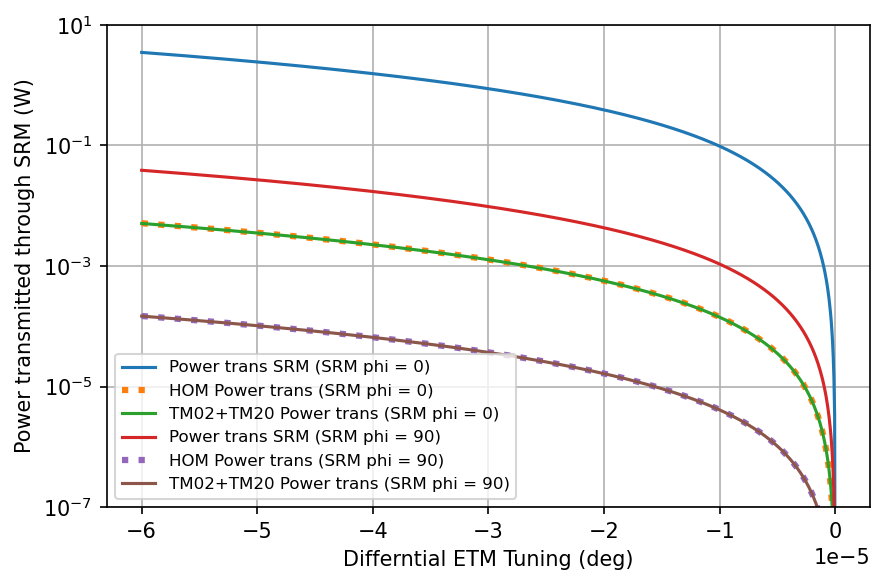

In [5]:
figure_size = (6,4)
plt.figure(figsize = figure_size,dpi = 150)
plt.semilogy(2*ETM_detuning_simulation_SRM_0.x,ETM_detuning_simulation_SRM_0['p_out'],label = 'Power trans SRM (SRM phi = 0)')
plt.semilogy(2*ETM_detuning_simulation_SRM_0.x,ETM_detuning_simulation_SRM_0['p_out_hOM'],linewidth = 3, linestyle = ':',label = 'HOM Power trans (SRM phi = 0)')
plt.semilogy(2*ETM_detuning_simulation_SRM_0.x,ETM_detuning_simulation_SRM_0['ad_HOM_2_y']**2+ ETM_detuning_simulation_SRM_0['ad_HOM_2_x']**2,label = 'TM02+TM20 Power trans (SRM phi = 0)')
plt.semilogy(2*ETM_detuning_simulation_SRM_90.x,ETM_detuning_simulation_SRM_90['p_out'],label = 'Power trans SRM (SRM phi = 90)')
plt.semilogy(2*ETM_detuning_simulation_SRM_90.x,ETM_detuning_simulation_SRM_90['p_out_hOM'],linewidth = 3, linestyle = ':',label = 'HOM Power trans (SRM phi = 90)')
plt.semilogy(2*ETM_detuning_simulation_SRM_90.x,ETM_detuning_simulation_SRM_90['ad_HOM_2_y']**2 + ETM_detuning_simulation_SRM_90['ad_HOM_2_x']**2,label = 'TM02+TM20 Power trans (SRM phi = 90)')
plt.legend(prop={'size': 8},loc = 'lower left')
plt.xlabel('Differntial ETM Tuning (deg)')
plt.ylabel('Power transmitted through SRM (W)')
#plt.title('Arm and SRC')
#plt.xlim([0.21354,0.21361])
plt.ylim([1e-7,10])
plt.tight_layout()
plt.grid()
plt.savefig('sim_chapter_Zoom_in_ETM_tuning.eps')
plt.show()


Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis sig1 f log 1 1e4
1000'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:37:08.584558


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 28.976 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:37:37.561525


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 43.8743 seconds


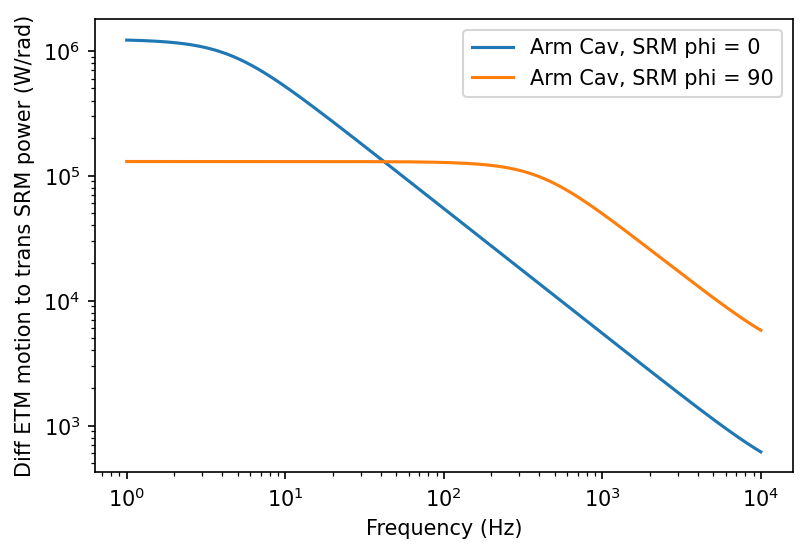


Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis SR3 f lin 17.967
18.003 100'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:38:23.400319


100% | ETA:  0:00:00 | Saving data                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 3.38427 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:38:26.785587


100% | ETA:  0:00:00 | Saving data                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 3.73565 seconds


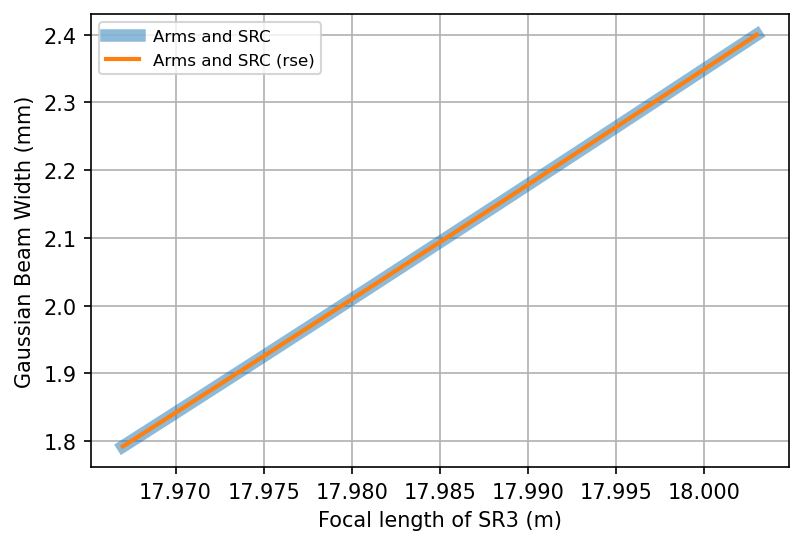

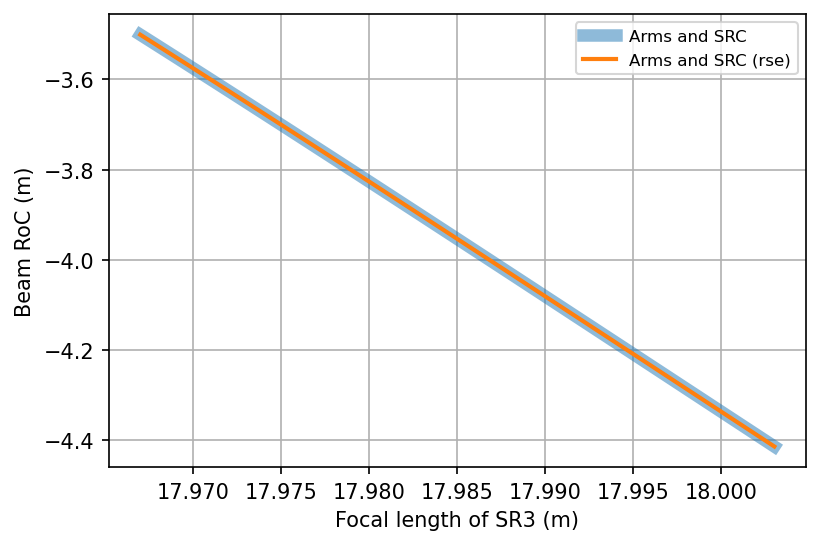

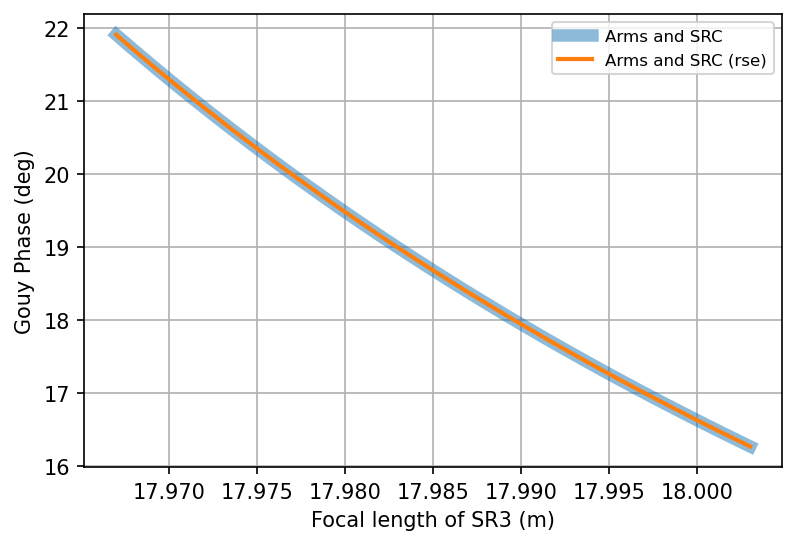

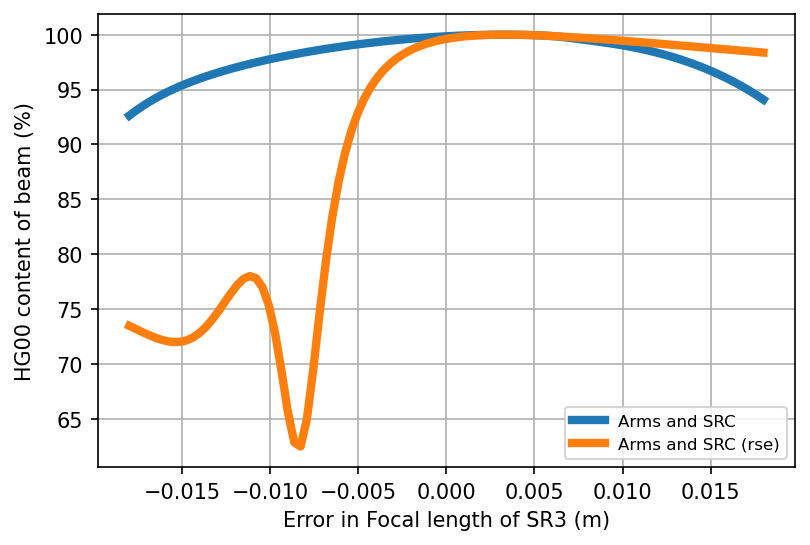

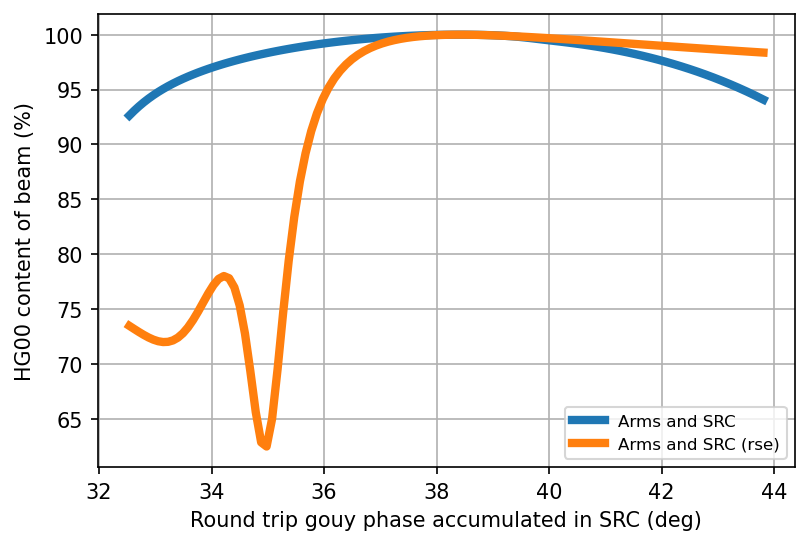

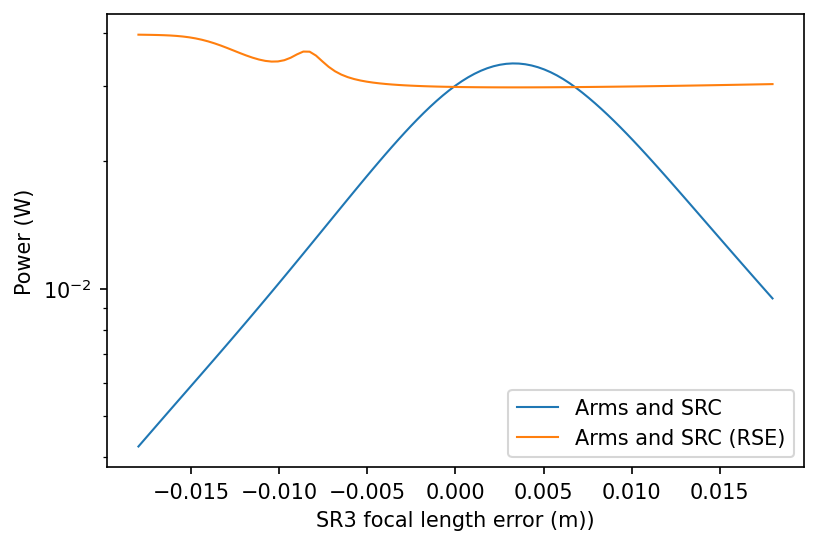

In [6]:
# this is verified by the simulation below.
etm_tuning_rse = ETM_detuning_simulation_SRM_90.x[idx_rse_arm]
etm_tuning_sr = ETM_detuning_simulation_SRM_0.x[idx_sr_arm]


##################################################################
# check for sr or rse mode
arm_cav_sr_and_rse_check = finesse.kat.deepcopy(michelson_with_FP_arms_and_src)

arm_cav_sr_and_rse_check.parse("""
maxtem 6
fsig sig1 ETMx 1 0 
fsig sig2 ETMy 1 180 
pd1 p_out_demod $fs nSRMd

pd1 sig_in $fs nETMx
ad arm_amp 0 nETMx

xaxis sig1 f log 1 1e4 1000

yaxis abs:deg
""")


arm_cav_sr_and_rse_check.SRM.phi = 0 #ref D0902838
arm_cav_sr_and_rse_check.ETMx.phi = etm_tuning_sr
arm_cav_sr_and_rse_check.ETMy.phi = -etm_tuning_sr
srm_phi_0_arm_cav = arm_cav_sr_and_rse_check.run()

#set to rse mode
arm_cav_sr_and_rse_check.SRM.phi = 90 #ref D0902838
arm_cav_sr_and_rse_check.ETMx.phi = etm_tuning_rse
arm_cav_sr_and_rse_check.ETMy.phi = -etm_tuning_rse
srm_phi_90_arm_cav = arm_cav_sr_and_rse_check.run()

plt.figure(figsize = figure_size,dpi = 150)
plt.loglog(srm_phi_0_arm_cav.x,np.abs(srm_phi_0_arm_cav['p_out_demod']),label = 'Arm Cav, SRM phi = 0')
plt.loglog(srm_phi_90_arm_cav.x,np.abs(srm_phi_90_arm_cav['p_out_demod']),label = 'Arm Cav, SRM phi = 90')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Diff ETM motion to trans SRM power (W/rad)')
plt.show()

##################################################################
# actual simulation we are intererested in 

#these are the 2sigma errors that are simulated over. For larger focal lengths,
#finesse requires a very high number of TEM to simulate properly
x1 = nominal_sr3_f - 3*0.006
x2 = nominal_sr3_f + 3*0.006

michelson_with_FP_arms_and_src.maxtem = 6
#parse the new xaxis command
michelson_with_FP_arms_and_src.parse('xaxis SR3 f lin {0} {1} 100'.format(x1,x2))

#michelson_with_FP_arms_and_src.parse('xaxis SR2 f lin {0} {1} 100'.format(-3.203-15e-3,-3.203+15e-3))

#this simulation is in signal recycling mode.
#due to jupyter notebook style programming, repeat the definition of SR mode.
michelson_with_FP_arms_and_src.SRM.phi = 0
michelson_with_FP_arms_and_src.ETMy.phi =  -etm_tuning_sr 
michelson_with_FP_arms_and_src.ETMx.phi =  etm_tuning_sr 
sim1 = michelson_with_FP_arms_and_src.run()

#set to rse mode
michelson_with_FP_arms_and_src.SRM.phi = 90 #ref D0902838
michelson_with_FP_arms_and_src.ETMy.phi =  -etm_tuning_rse 
michelson_with_FP_arms_and_src.ETMx.phi =  etm_tuning_rse 
sim1_with_rse = michelson_with_FP_arms_and_src.run()
#####
# finished with the interferometer with arms


plt.figure(figsize = figure_size,dpi = 150)
plt.plot(sim1.x,1000*sim1['SRM_trans_w'],linewidth = 6,alpha = 0.5,label = 'Arms and SRC')
plt.plot(sim1_with_rse.x,1000*sim1_with_rse['SRM_trans_w'],linewidth = 2,label = 'Arms and SRC (rse)')
plt.xlabel('Focal length of SR3 (m)')
plt.legend(prop={'size': 8})
plt.ylabel('Gaussian Beam Width (mm)')
plt.grid()
#plt.title('SRM beam Width as a function of SR3 focal length')
#plt.savefig(fname = 'beam_size_simulated.pdf',dpi = 150)
plt.show()

######################
plt.figure(figsize = figure_size,dpi = 150)
plt.plot(sim1.x,sim1['SRM_trans_r'],linewidth = 6,alpha = 0.5,label = 'Arms and SRC')
plt.plot(sim1_with_rse.x,sim1_with_rse['SRM_trans_r'],linewidth = 2,label = 'Arms and SRC (rse)')
plt.xlabel('Focal length of SR3 (m)')
plt.legend(prop={'size': 8})
plt.ylabel('Beam RoC (m)')
plt.grid()
#plt.savefig(fname = 'beam_roc_simulated.pdf',dpi = 150)
plt.show()

#########################

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(sim1.x,sim1['src_gouy'],linewidth = 6,alpha = 0.5,label = 'Arms and SRC' )
plt.plot(sim1_with_rse.x,sim1_with_rse['src_gouy'],linewidth = 2,label = 'Arms and SRC (rse)')
plt.xlabel('Focal length of SR3 (m)')
plt.ylabel('Gouy Phase (deg)')
#plt.title('SRC Round Trip Gouy Phase as a function of SR3 focal length')
plt.legend(prop={'size': 8})
plt.grid()
#plt.savefig(fname = 'gouy_simulated.pdf',dpi = 150)
plt.show()

####################################################################

######################## Ratio Plots ###############################

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(17.985-sim1.x,100*(1-sim1['p_out_hOM']/sim1['p_out']),linewidth = 4,label = 'Arms and SRC')
plt.plot(17.985-sim1_with_rse.x,100*(1-sim1_with_rse['p_out_hOM']/sim1_with_rse['p_out']),linewidth = 4,label = 'Arms and SRC (rse)')
plt.xlabel('Error in Focal length of SR3 (m)')
plt.ylabel('HG00 content of beam (%)')
plt.legend(prop={'size': 8})
plt.grid()
#plt.savefig(fname = 'TM00_simulated.pdf',dpi = 150)
plt.show()

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(2*sim1['src_gouy'],100*(1-sim1['p_out_hOM']/sim1['p_out']),linewidth = 4,label = 'Arms and SRC')
plt.plot(2*sim1['src_gouy'],100*(1-sim1_with_rse['p_out_hOM']/sim1_with_rse['p_out']),linewidth = 4,linestyle = '-',label = 'Arms and SRC (rse)')
plt.xlabel('Round trip gouy phase accumulated in SRC (deg)')
plt.ylabel('HG00 content of beam (%)')
plt.legend(prop={'size': 8})
plt.grid()
#plt.savefig(fname = 'ratio_powers.pdf',dpi = 150)
plt.show()


####################################################################

######################## Power Plots ###############################

sim1_HG00_power = sim1['p_out'] - sim1['p_out_hOM']
sim1_with_rse_HG00_power = sim1_with_rse['p_out'] - sim1_with_rse['p_out_hOM']

plt.figure(figsize = figure_size,dpi = 150)
#plt.semilogy(17.985-sim1.x,sim1['p_out'],linewidth = 1,color = 'tab:blue',alpha = 0.3,label = 'Arms and SRC')
#plt.semilogy(17.985-sim1.x,sim1['p_out_hOM'],linewidth = 1,color = 'tab:blue',alpha = 0.7,label = 'Arms and SRC')
plt.semilogy(17.985-sim1.x,sim1_HG00_power,linewidth = 1,color = 'tab:blue',label = 'Arms and SRC')

#plt.semilogy(17.985-sim1_with_rse.x,sim1_with_rse['p_out'],linewidth = 1,color = 'tab:orange',alpha = 0.3,label = 'Arms and SRC (RSE)')
#plt.semilogy(17.985-sim1_with_rse.x,sim1_with_rse['p_out_hOM'],linewidth = 1,color = 'tab:orange',alpha = 0.7,label = 'Arms and SRC (RSE)')
plt.semilogy(17.985-sim1_with_rse.x,sim1_with_rse_HG00_power,linewidth = 1,color = 'tab:orange',label = 'Arms and SRC (RSE)')
plt.ylabel('Power (W)')
plt.xlabel('SR3 focal length error (m))')
plt.legend()
plt.show()

# No arm cavities
This simulation is constructed in a similar way to the previous one. The first thing that is done is is a copy of `michelson_with_FP_arms_and_src` is made. This is called  `ITM_detuning_simulation`. The reflectivity of the ITMs is set to nearly 1:

```
ITM_L = 10e-6
ITM_detuning_simulation.ITMx.R = 1 - ITM_L
ITM_detuning_simulation.ITMx.T = 0
ITM_detuning_simulation.ITMx.L = ITM_L

ITM_detuning_simulation.ITMy.R = 1 - ITM_L
ITM_detuning_simulation.ITMy.T = 0
ITM_detuning_simulation.ITMy.L = ITM_L
```
The same detuning experiment as for the interfoermeter with arm cavities was performed, except this time the ITMs where detuned.

A new simulation was set up to check what SRM detuning corresponded to what mode of operation. It was found that with the SRM set to 90 deg detuning the transmitted signal through the SRM was larger than when it was set to 0 deg, suggesting that 90 degree detuning is the signal recycling mode.

The RoC error simuation is then run. This is created using 
```
michelson_small_arms_and_src = finesse.kat.deepcopy(michelson_with_FP_arms_and_src)
```


In [7]:
ITM_detuning_simulation = finesse.kat.deepcopy(michelson_with_FP_arms_and_src)

ITM_L = 10e-6
ITM_detuning_simulation.ITMx.R = 1 - ITM_L
ITM_detuning_simulation.ITMx.T = 0
ITM_detuning_simulation.ITMx.L = ITM_L

ITM_detuning_simulation.ITMy.R = 1 - ITM_L
ITM_detuning_simulation.ITMy.T = 0
ITM_detuning_simulation.ITMy.L = ITM_L


nominal_sr3_f = 17.985
ITM_L = 10e-6
#print(appendix_b.SR3.f)
ITM_detuning_simulation.SR3.f =  nominal_sr3_f #-0.00184678655646107
#print(appendix_b.SR3.f)

ITM_detuning_simulation.parse("""
maxtem 6
xaxis ITMx phi lin -0.01 0 1000
func ITMy_phi = (-1)*$x1
put ITMy phi ITMy_phi
""")
ITM_detuning_simulation.SRM.phi = 0 #89.9989780433498 #ref D0902838
ITM_detuning_simulation_SRM_0 = ITM_detuning_simulation.run()


ITM_detuning_simulation.SRM.phi = 90 #89.9989780433498 #ref D0902838
ITM_detuning_simulation_SRM_90 = ITM_detuning_simulation.run()


idx_0_no_arm = (np.abs(ITM_detuning_simulation_SRM_0['p_out'] - 30e-3)).argmin()
print('IFO with Arm Cavs \n SRM phi = 0')
print('Power = {0:.1f} mW'.format(ITM_detuning_simulation_SRM_0['p_out'][idx_0_no_arm]*1000))
print('detuning of each ITM = +- {0}'.format(ITM_detuning_simulation_SRM_0.x[idx_0_no_arm]))
print('Differential detuning ITM = {0}'.format(2*ITM_detuning_simulation_SRM_0.x[idx_0_no_arm]))

idx_90_no_arm = (np.abs(ITM_detuning_simulation_SRM_90['p_out'] - 30e-3)).argmin()      
print('----------------\n SRM phi = 90')
print('Power = {0:.1f} mW'.format(ITM_detuning_simulation_SRM_90['p_out'][idx_90_no_arm]*1000))
print('detuning of each ITM = +- {0}'.format(ITM_detuning_simulation_SRM_90.x[idx_90_no_arm]))
print('Differential detuning ITM = {0}'.format(2*ITM_detuning_simulation_SRM_90.x[idx_90_no_arm]))


Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis ITMx phi lin -0.01
0 1000'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:38:34.395079


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 11.8363 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:38:46.232426


 95% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 12.6891 seconds
IFO with Arm Cavs 
 SRM phi = 0
Power = 30.0 mW
detuning of each ITM = +- -0.00709
Differential detuning ITM = -0.01418
----------------
 SRM phi = 90
Power = 29.6 mW
detuning of each ITM = +- -0.000739999999999999
Differential detuning ITM = -0.001479999999999998


100% | ETA:  0:00:00 | Calculating                                             

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


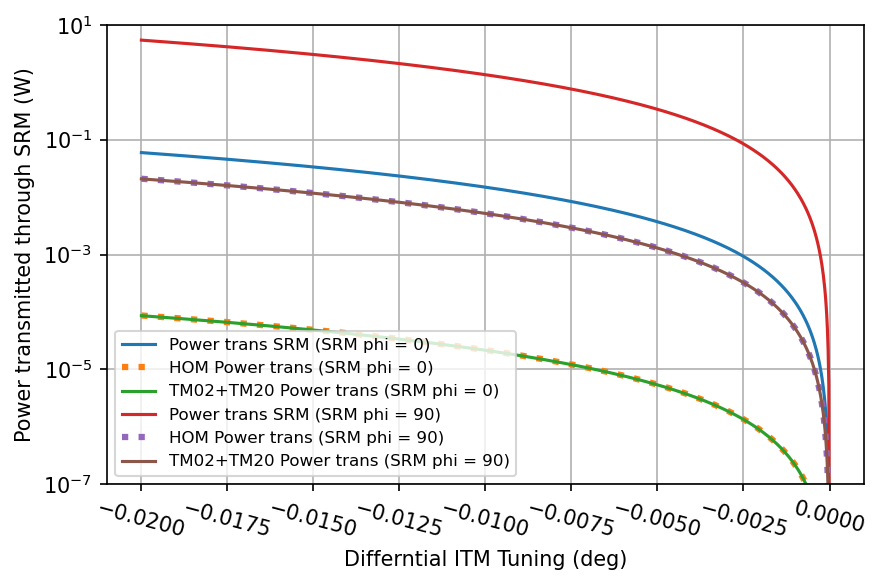

In [8]:
figure_size = (6,4)
plt.figure(figsize = figure_size,dpi = 150)
plt.semilogy(2*ITM_detuning_simulation_SRM_0.x,ITM_detuning_simulation_SRM_0['p_out'],label = 'Power trans SRM (SRM phi = 0)')
plt.semilogy(2*ITM_detuning_simulation_SRM_0.x,ITM_detuning_simulation_SRM_0['p_out_hOM'],linewidth = 3, linestyle = ':',label = 'HOM Power trans (SRM phi = 0)')
plt.semilogy(2*ITM_detuning_simulation_SRM_0.x,ITM_detuning_simulation_SRM_0['ad_HOM_2_y']**2+ ITM_detuning_simulation_SRM_0['ad_HOM_2_x']**2,label = 'TM02+TM20 Power trans (SRM phi = 0)')
plt.semilogy(2*ITM_detuning_simulation_SRM_90.x,ITM_detuning_simulation_SRM_90['p_out'],label = 'Power trans SRM (SRM phi = 90)')
plt.semilogy(2*ITM_detuning_simulation_SRM_90.x,ITM_detuning_simulation_SRM_90['p_out_hOM'],linewidth = 3, linestyle = ':',label = 'HOM Power trans (SRM phi = 90)')
plt.semilogy(2*ITM_detuning_simulation_SRM_90.x,ITM_detuning_simulation_SRM_90['ad_HOM_2_y']**2 + ITM_detuning_simulation_SRM_90['ad_HOM_2_x']**2,label = 'TM02+TM20 Power trans (SRM phi = 90)')
plt.legend(prop={'size': 8},loc = 'lower left')
plt.xlabel('Differntial ITM Tuning (deg)')
plt.xticks(rotation = -15)
plt.ylabel('Power transmitted through SRM (W)')
#plt.title('Arm and SRC')
#plt.xlim([0.21354,0.21361])
plt.ylim([1e-7,10])
plt.tight_layout()
plt.grid()
plt.savefig('sim_chapter_Zoom_in_ITM_tuning.eps')
plt.show()


Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis sig1 f log 1 1e4
1000'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:39:01.564506


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 40.5555 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:39:42.121000


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 39.5752 seconds


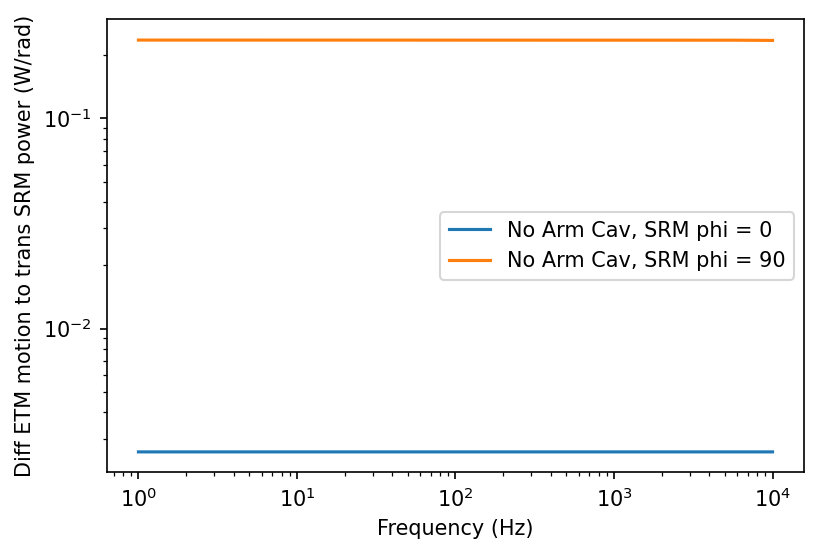


Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis SR3 f lin 17.967
18.003 100'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:40:23.434570


100% | ETA:  0:00:00 | Saving data                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 3.4408 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:40:26.876366


100% | ETA:  0:00:00 | Saving data                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 2.89227 seconds


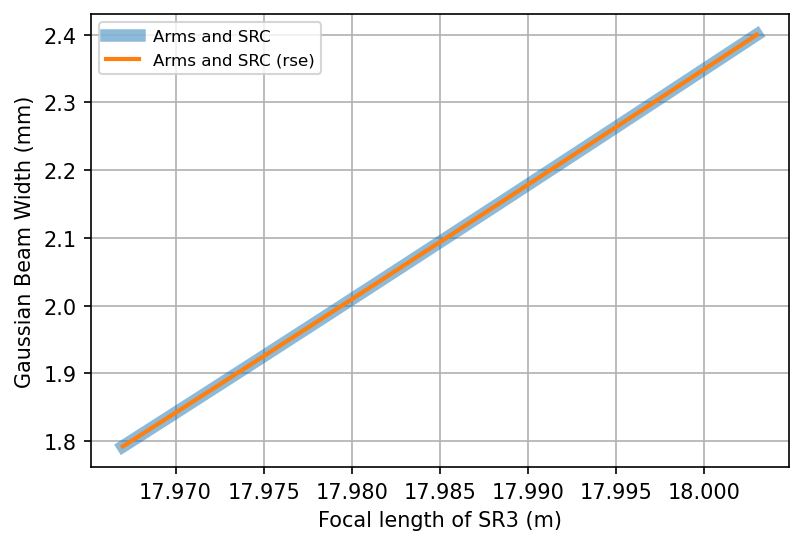

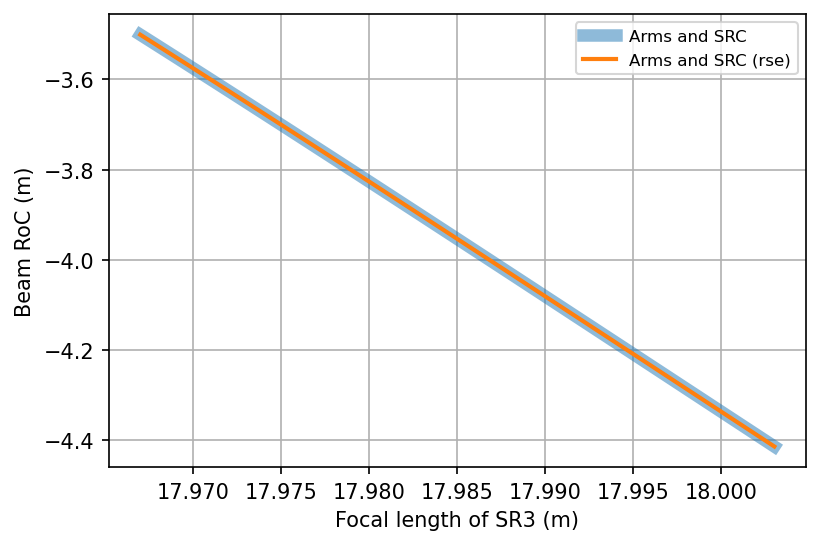

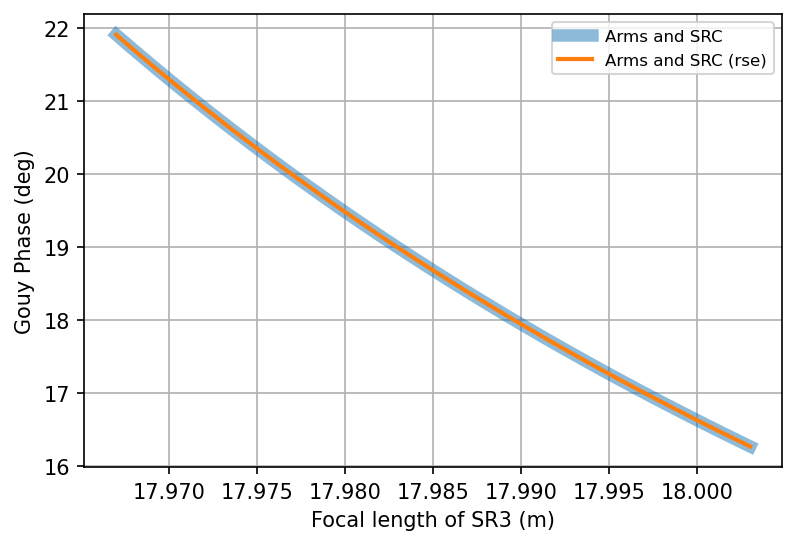

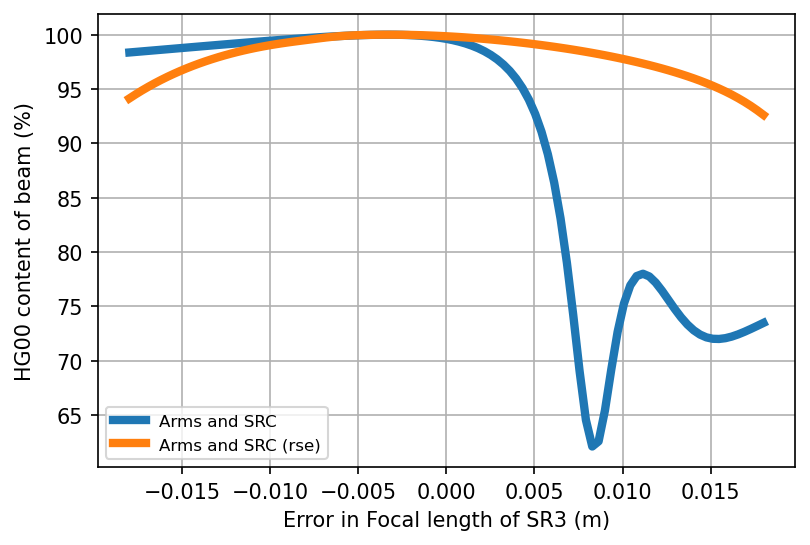

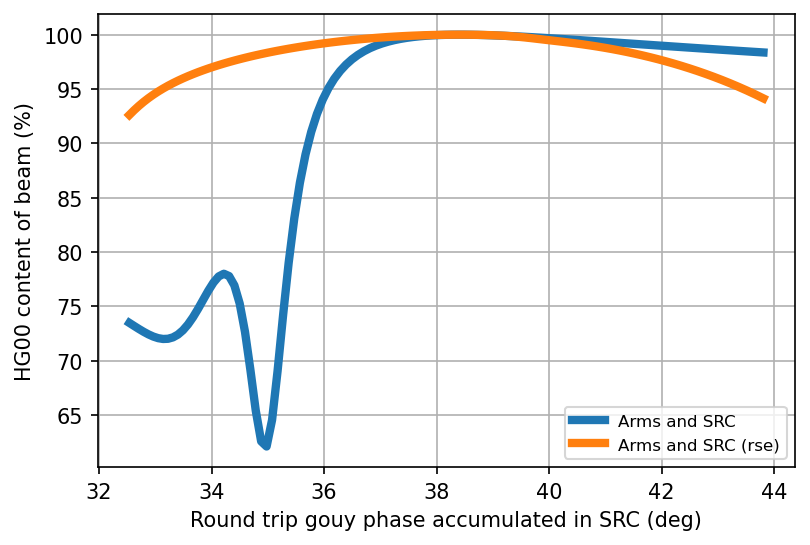

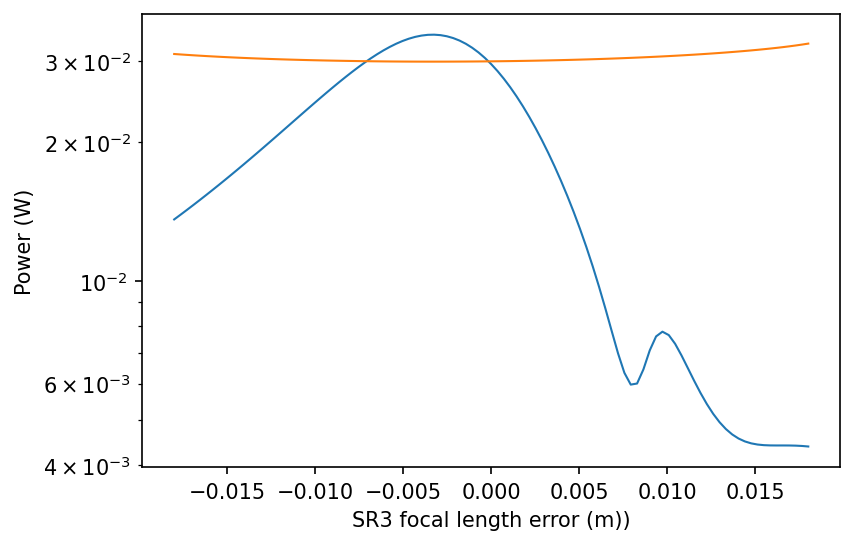

In [9]:
# this is verified by the simulation below.
ITM_tuning_0 = ITM_detuning_simulation_SRM_0.x[idx_0_no_arm]
ITM_tuning_90 = ITM_detuning_simulation_SRM_90.x[idx_90_no_arm]

####################################################################
# check for sr or rse mode
no_arm_cav_sr_and_rse_check = finesse.kat.deepcopy(michelson_with_FP_arms_and_src)

no_arm_cav_sr_and_rse_check.ITMx.R = 1 - ITM_L
no_arm_cav_sr_and_rse_check.ITMx.T = 0
no_arm_cav_sr_and_rse_check.ITMx.L = ITM_L

no_arm_cav_sr_and_rse_check.ITMy.R = 1 - ITM_L
no_arm_cav_sr_and_rse_check.ITMy.T = 0
no_arm_cav_sr_and_rse_check.ITMy.L = ITM_L

no_arm_cav_sr_and_rse_check.parse("""
maxtem 6
fsig sig1 ITMx 1 0 
fsig sig2 ITMy 1 180 

pd1 p_out_demod $fs nSRMd
pd1 sig_in $fs nITMxHRa
ad arm_amp 0 nETMx

xaxis sig1 f log 1 1e4 1000

yaxis abs:deg
""")


no_arm_cav_sr_and_rse_check.SRM.phi = 0 #ref D0902838
no_arm_cav_sr_and_rse_check.ETMx.phi = ITM_tuning_0
no_arm_cav_sr_and_rse_check.ETMy.phi = -ITM_tuning_0
srm_phi_0_no_arm_cav = no_arm_cav_sr_and_rse_check.run()

#set to rse mode
no_arm_cav_sr_and_rse_check.SRM.phi = 90 #ref D0902838
no_arm_cav_sr_and_rse_check.ETMx.phi = ITM_tuning_90
no_arm_cav_sr_and_rse_check.ETMy.phi = -ITM_tuning_90
srm_phi_90_no_arm_cav = no_arm_cav_sr_and_rse_check.run()

plt.figure(figsize = figure_size,dpi = 150)
plt.loglog(srm_phi_0_no_arm_cav.x,np.abs(srm_phi_0_no_arm_cav['p_out_demod']),label = 'No arm cavity, SRM phi = 0')
plt.loglog(srm_phi_90_no_arm_cav.x,np.abs(srm_phi_90_no_arm_cav['p_out_demod']),label = 'No Arm cavity, SRM phi = 90')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Diff ETM motion to trans SRM power (W/rad)')
plt.show()
####################################################################

#these are the 2sigma errors that are simulated over. For larger focal lengths,
#finesse requires a very high number of TEM to simulate properly
x1 = nominal_sr3_f - 3*0.006
x2 = nominal_sr3_f + 3*0.006

michelson_small_arms_and_src = finesse.kat.deepcopy(michelson_with_FP_arms_and_src)

ITM_L = 0
michelson_small_arms_and_src.ITMx.R = 1 - ITM_L
michelson_small_arms_and_src.ITMx.T = 0
michelson_small_arms_and_src.ITMx.L = ITM_L

michelson_small_arms_and_src.ITMy.R = 1 - ITM_L
michelson_small_arms_and_src.ITMy.T = 0
michelson_small_arms_and_src.ITMy.L = ITM_L


michelson_small_arms_and_src.maxtem = 6
#parse the new xaxis command
michelson_small_arms_and_src.parse('xaxis SR3 f lin {0} {1} 100'.format(x1,x2))

#michelson_small_arms_and_src.parse('xaxis SR2 f lin {0} {1} 100'.format(-3.203-15e-3,-3.203+15e-3))
#this simulation is in signal recycling mode.
#due to jupyter notebook style programming, repeat the definition of SR mode.
michelson_small_arms_and_src.SRM.phi = 0
michelson_small_arms_and_src.ITMy.phi =  -ITM_tuning_0 
michelson_small_arms_and_src.ITMx.phi =  ITM_tuning_0 
sim2_with_rse = michelson_small_arms_and_src.run()

#set to rse mode
michelson_small_arms_and_src.SRM.phi = 90 #ref D0902838

michelson_small_arms_and_src.ITMy.phi =  -ITM_tuning_90 
michelson_small_arms_and_src.ITMx.phi =  ITM_tuning_90 
sim2 = michelson_small_arms_and_src.run()
#####
# finished with the interferometer with arms


plt.figure(figsize = figure_size,dpi = 150)
plt.plot(sim2.x,1000*sim2['SRM_trans_w'],linewidth = 6,alpha = 0.5,label = 'Arms and SRC')
plt.plot(sim2_with_rse.x,1000*sim2_with_rse['SRM_trans_w'],linewidth = 2,label = 'Arms and SRC (rse)')
plt.xlabel('Focal length of SR3 (m)')
plt.legend(prop={'size': 8})
plt.ylabel('Gaussian Beam Width (mm)')
plt.grid()
#plt.title('SRM beam Width as a function of SR3 focal length')
#plt.savefig(fname = 'beam_size_simulated.pdf',dpi = 150)
plt.show()

######################
plt.figure(figsize = figure_size,dpi = 150)
plt.plot(sim2.x,sim2['SRM_trans_r'],linewidth = 6,alpha = 0.5,label = 'Arms and SRC')
plt.plot(sim2_with_rse.x,sim2_with_rse['SRM_trans_r'],linewidth = 2,label = 'Arms and SRC (rse)')
plt.xlabel('Focal length of SR3 (m)')
plt.legend(prop={'size': 8})
plt.ylabel('Beam RoC (m)')
plt.grid()
#plt.savefig(fname = 'beam_roc_simulated.pdf',dpi = 150)
plt.show()

#########################

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(sim2.x,sim2['src_gouy'],linewidth = 6,alpha = 0.5,label = 'Arms and SRC' )
plt.plot(sim2_with_rse.x,sim2_with_rse['src_gouy'],linewidth = 2,label = 'Arms and SRC (rse)')
plt.xlabel('Focal length of SR3 (m)')
plt.ylabel('Gouy Phase (deg)')
#plt.title('SRC Round Trip Gouy Phase as a function of SR3 focal length')
plt.legend(prop={'size': 8})
plt.grid()
#plt.savefig(fname = 'gouy_simulated.pdf',dpi = 150)
plt.show()

####################################################################

######################## Ratio Plots ###############################

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(sim2.x-17.985,100*(1-sim2['p_out_hOM']/sim2['p_out']),linewidth = 4,label = 'Arms and SRC')
plt.plot(sim2_with_rse.x-17.985,100*(1-sim2_with_rse['p_out_hOM']/sim2_with_rse['p_out']),linewidth = 4,label = 'Arms and SRC (rse)')
plt.xlabel('Error in Focal length of SR3 (m)')
plt.ylabel('HG00 content of beam (%)')
plt.legend(prop={'size': 8})
plt.grid()
#plt.savefig(fname = 'TM00_simulated.pdf',dpi = 150)
plt.show()

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(2*sim2['src_gouy'],100*(1-sim2['p_out_hOM']/sim2['p_out']),linewidth = 4,label = 'Arms and SRC')
plt.plot(2*sim2['src_gouy'],100*(1-sim2_with_rse['p_out_hOM']/sim2_with_rse['p_out']),linewidth = 4,linestyle = '-',label = 'Arms and SRC (rse)')
plt.xlabel('Round trip gouy phase accumulated in SRC (deg)')
plt.ylabel('HG00 content of beam (%)')
plt.legend(prop={'size': 8})
plt.grid()
#plt.savefig(fname = 'ratio_powers.pdf',dpi = 150)
plt.show()


####################################################################

######################## Power Plots ###############################

sim2_HG00_power = sim2['p_out'] - sim2['p_out_hOM']
sim2_with_rse_HG00_power = sim2_with_rse['p_out'] - sim2_with_rse['p_out_hOM']

plt.figure(figsize = figure_size,dpi = 150)
#plt.semilogy(17.985-sim2.x,sim2['p_out'],linewidth = 1,color = 'tab:blue',alpha = 0.3,label = 'Arms and SRC')
#plt.semilogy(17.985-sim2.x,sim2['p_out_hOM'],linewidth = 1,color = 'tab:blue',alpha = 0.7,label = 'Arms and SRC')
plt.semilogy(sim2.x-17.985,sim2_HG00_power,linewidth = 1,color = 'tab:blue',label = 'Arms and SRC')

#plt.semilogy(17.985-sim2_with_rse.x,sim2_with_rse['p_out'],linewidth = 1,color = 'tab:orange',alpha = 0.3,label = 'Arms and SRC (RSE)')
#plt.semilogy(17.985-sim2_with_rse.x,sim2_with_rse['p_out_hOM'],linewidth = 1,color = 'tab:orange',alpha = 0.7,label = 'Arms and SRC (RSE)')
plt.semilogy(sim2_with_rse.x-17.985,sim2_with_rse_HG00_power,linewidth = 1,color = 'tab:orange',label = 'Arms and SRC (RSE)')
plt.ylabel('Power (W)')
plt.xlabel('SR3 focal length error (m))')
plt.show()

# Plots for RoC error in SR3 for both Simulations

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


beam width at ITM = 53.0 mm.
beam width at SRM = 2.1 mm.
beam RoC at SRM = -4.0 m.
Power in:  5000000.000000
Power ref:  4973195.541278
Power out:  0.029493
HOM power out:  4.328199e-05
HOM % :  0.146752
Gouy Phase accumulated within SRC = 18.6798330284094


Power out sanity check:  0.029493
Power out sim1:  0.010076
Power out sim1_with_rse:  0.030836


Power out sim2:  0.013834
Power out sim2_with_rse:  0.032977


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

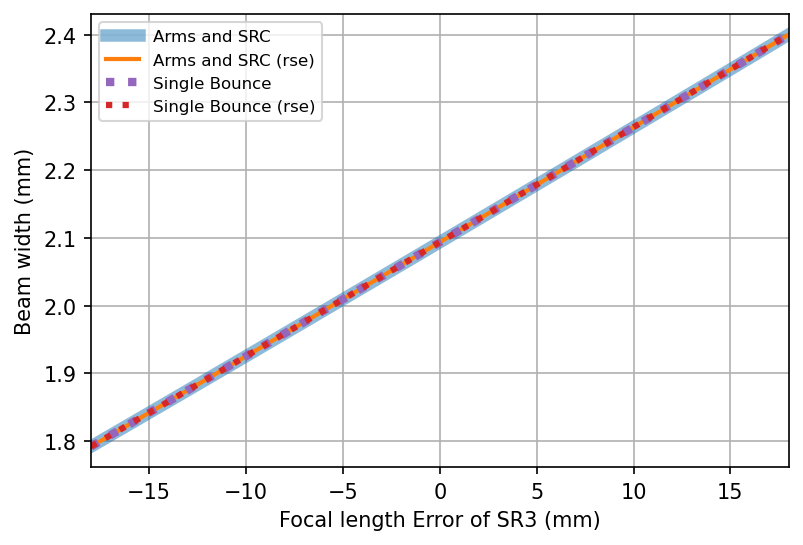

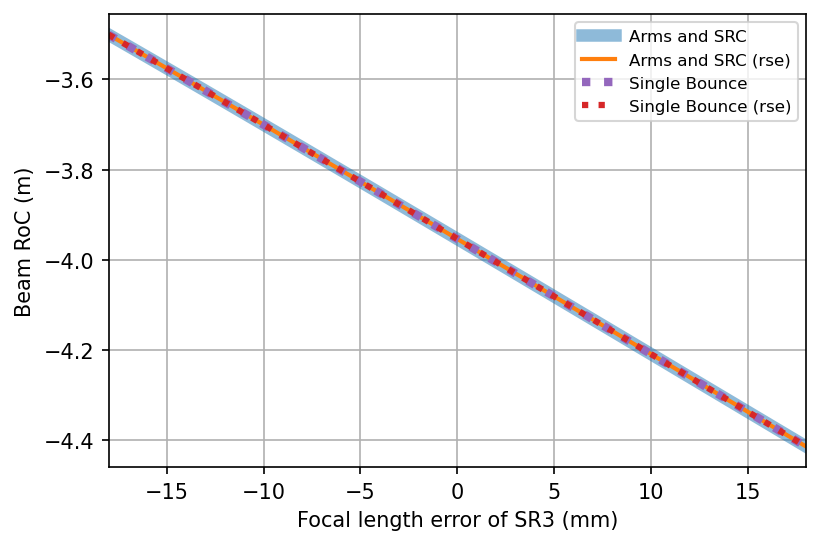

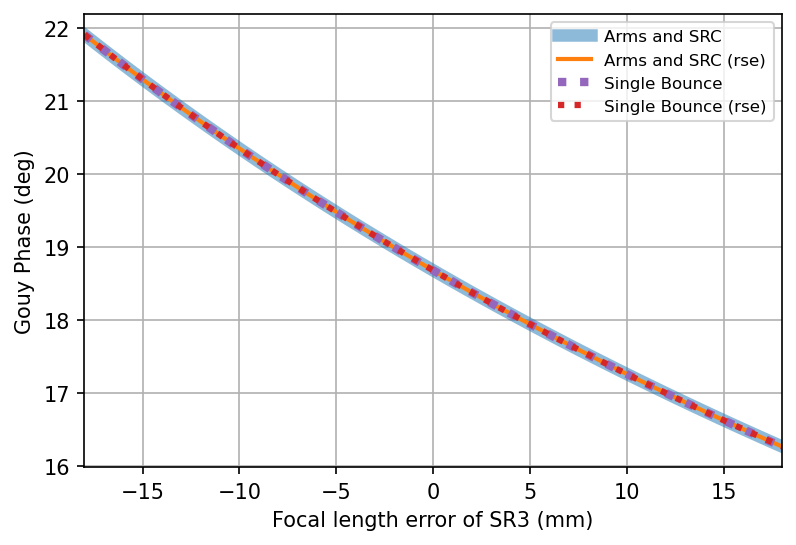

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


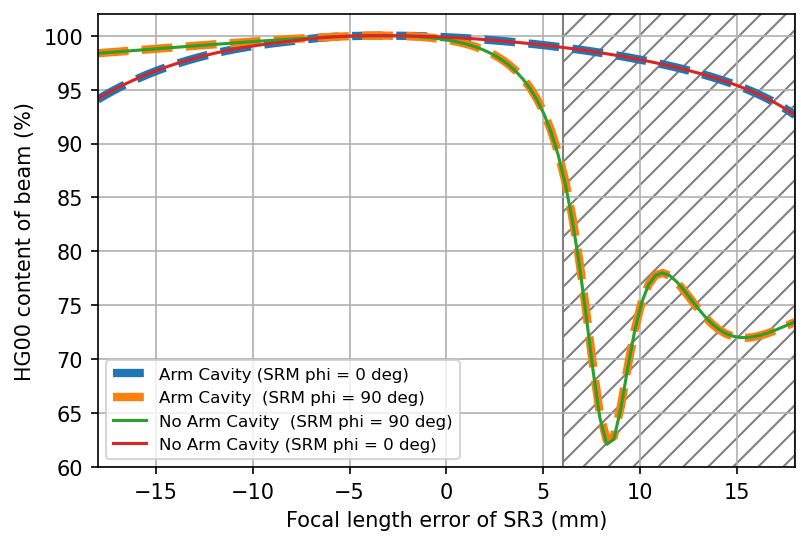

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

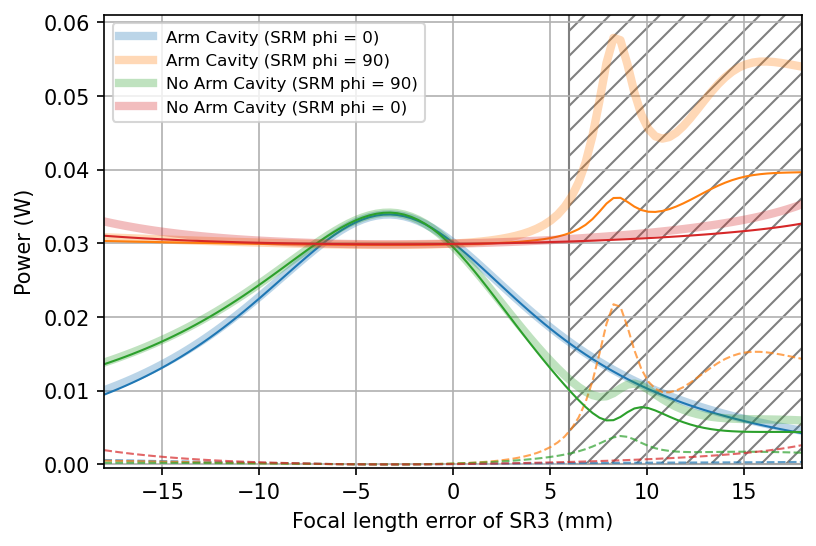

In [10]:
nom_value = 17.985
#nom_value = -3.203

figure_size = (6,4)
################################################################
print('beam width at ITM = {0:.1f} mm.'.format(ITM_width*1000))
print('beam width at SRM = {0:.1f} mm.'.format(SRM_width_w*1000))
print('beam RoC at SRM = {0:.1f} m.'.format(sanity_check['SRM_trans_r'][0]))
print('Power in:  {0:.6f}'.format(sanity_check['p_in'][0]))
print('Power ref:  {0:.6f}'.format(sanity_check['p_ref'][0]))
print('Power out:  {0:.6f}'.format(sanity_check['p_out'][0]))
print('HOM power out:  {0:.6e}'.format(sanity_check['p_out_hOM'][0]))
print('HOM % :  {0:.6f}'.format(100*sanity_check['p_out_hOM'][0]/sanity_check['p_out'][0]))
print('Gouy Phase accumulated within SRC = {0}'.format(sanity_check['src_gouy'][0]))
#print('Laser Beam Parameters: w0 = {0:6e} m, z = {1:6e} m'.format(FP_michelson_out['laser_w'][0],FP_michelson_out['laser_z'][0]))

print('\n')
print('Power out sanity check:  {0:.6f}'.format(sanity_check['p_out'][0]))
print('Power out sim1:  {0:.6f}'.format(sim1['p_out'][0]))
print('Power out sim1_with_rse:  {0:.6f}'.format(sim1_with_rse['p_out'][0]))
print('\n')
print('Power out sim2:  {0:.6f}'.format(sim2['p_out'][0]))
print('Power out sim2_with_rse:  {0:.6f}'.format(sim2_with_rse['p_out'][0]))

################################################################

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(1e3*(sim1.x -nom_value),1000*sim1['SRM_trans_w'],linewidth = 6,alpha = 0.5,label = 'Arms and SRC')
plt.plot(1e3*(sim1_with_rse.x -nom_value),1000*sim1_with_rse['SRM_trans_w'],linewidth = 2,label = 'Arms and SRC (rse)')
plt.plot(1e3*(sim2.x -nom_value),1000*sim2['SRM_trans_w'],linewidth = 4,linestyle = ':',color = 'tab:purple',label = 'Single Bounce')
plt.plot(1e3*(sim2_with_rse.x -nom_value),1000*sim2_with_rse['SRM_trans_w'],linewidth = 3,linestyle = ':',color = 'tab:red',label = 'Single Bounce (rse)')

plt.xlabel('Focal length Error of SR3 (mm)')
plt.legend(prop={'size': 8})
plt.ylabel('Beam width (mm)')
plt.grid()
plt.xlim([-18,18])
plt.savefig(fname = 'sim_chapter_sim_chapter_beam_size_simulated.eps',dpi = 150)

######################
plt.figure(figsize = figure_size,dpi = 150)
plt.plot(1e3*(sim1.x -nom_value),sim1['SRM_trans_r'],linewidth = 6,alpha = 0.5,label = 'Arms and SRC')
plt.plot(1e3*(sim1_with_rse.x -nom_value),sim1_with_rse['SRM_trans_r'],linewidth = 2,label = 'Arms and SRC (rse)')
plt.plot(1e3*(sim2.x -nom_value),sim2['SRM_trans_r'],linewidth = 4,linestyle = ':',color = 'tab:purple',label = 'Single Bounce')
plt.plot(1e3*(sim2_with_rse.x -nom_value),sim2_with_rse['SRM_trans_r'],linewidth = 3,linestyle = ':',color = 'tab:red',label = 'Single Bounce (rse)')
plt.xlabel('Focal length error of SR3 (mm)')
plt.legend(prop={'size': 8})
plt.ylabel('Beam RoC (m)')
plt.grid()
plt.xlim([-18,18])
plt.savefig(fname = 'sim_chapter_beam_roc_simulated.eps',dpi = 150)


#########################

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(1e3*(sim1.x -nom_value),sim1['src_gouy'],linewidth = 6,alpha = 0.5,label = 'Arms and SRC' )
plt.plot(1e3*(sim1_with_rse.x -nom_value),sim1_with_rse['src_gouy'],linewidth = 2,label = 'Arms and SRC (rse)')
plt.plot(1e3*(sim2.x -nom_value),sim2['src_gouy'],linewidth = 4,linestyle = ':',color = 'tab:purple',label = 'Single Bounce' )
plt.plot(1e3*(sim2_with_rse.x -nom_value),sim2_with_rse['src_gouy'],linewidth = 3,linestyle = ':',color = 'tab:red',label = 'Single Bounce (rse)')
plt.xlabel('Focal length error of SR3 (mm)')
plt.ylabel('Gouy Phase (deg)')
#plt.title('SRC Round Trip Gouy Phase as a function of SR3 focal length')
plt.legend(prop={'size': 8})
plt.grid()
plt.xlim([-18,18])
plt.savefig(fname = 'sim_chapter_gouy_simulated.eps',dpi = 150)
plt.show()
####################################################################

######################## Ratio Plots ###############################

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(1e3*(sim1.x -nom_value),100*(1-sim1['p_out_hOM']/sim1['p_out']),linewidth = 4,linestyle = '--',label = 'Arm Cavity (SRM phi = 0 deg)')
plt.plot(1e3*(sim1_with_rse.x -nom_value),100*(1-sim1_with_rse['p_out_hOM']/sim1_with_rse['p_out']),linewidth = 4,linestyle = '--',label = 'Arm Cavity  (SRM phi = 90 deg)')
plt.plot(1e3*(sim2.x -nom_value),100*(1-sim2['p_out_hOM']/sim2['p_out']),label = 'No Arm Cavity  (SRM phi = 90 deg)')
plt.plot(1e3*(sim2_with_rse.x -nom_value),100*(1-sim2_with_rse['p_out_hOM']/sim2_with_rse['p_out']),label = 'No Arm Cavity (SRM phi = 0 deg)')
plt.xlabel('Focal length error of SR3 (mm)')
plt.ylabel('HG00 content of beam (%)')
plt.legend(prop={'size': 8})
plt.grid()
plt.fill([6,18,18,6],[0,0,110,110],fill =False,c='gray',hatch = '//')
plt.ylim([60,102])
plt.xlim([-18,18])
plt.savefig(fname = 'sim_chapter_TM00_simulated.eps',dpi = 150)
plt.show()


####################################################################

######################## Power Plots ###############################

sim1_HG00_power = sim1['p_out'] - sim1['p_out_hOM']
sim1_with_rse_HG00_power = sim1_with_rse['p_out'] - sim1_with_rse['p_out_hOM']

sim2_HG00_power = sim2['p_out'] - sim2['p_out_hOM']
sim2_with_rse_HG00_power = sim2_with_rse['p_out'] - sim2_with_rse['p_out_hOM']

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(1e3*(sim1.x - nom_value),sim1['p_out'],linewidth = 4,color = 'tab:blue',alpha = 0.3,label = 'Arm Cavity (SRM phi = 0)')
plt.plot(1e3*(sim1.x - nom_value),sim1['p_out_hOM'],linewidth = 1,linestyle = '--',color = 'tab:blue',alpha = 0.7)
plt.plot(1e3*(sim1.x - nom_value),sim1_HG00_power,linewidth = 1,color = 'tab:blue')

plt.plot(1e3*(sim1_with_rse.x - nom_value),sim1_with_rse['p_out'],linewidth = 4,color = 'tab:orange',alpha = 0.3,label = 'Arm Cavity (SRM phi = 90)')
plt.plot(1e3*(sim1_with_rse.x - nom_value),sim1_with_rse['p_out_hOM'],linewidth = 1,linestyle = '--',color = 'tab:orange',alpha = 0.7)
plt.plot(1e3*(sim1_with_rse.x - nom_value),sim1_with_rse_HG00_power,linewidth = 1,color = 'tab:orange')

plt.plot(1e3*(sim2.x - nom_value),sim2['p_out'],linewidth = 4,color = 'tab:green',alpha = 0.3,label = 'No Arm Cavity (SRM phi = 90)')
plt.plot(1e3*(sim2.x - nom_value),sim2['p_out_hOM'],linewidth = 1,linestyle = '--',color = 'tab:green',alpha = 0.7)
plt.plot(1e3*(sim2.x - nom_value),sim2_HG00_power,linewidth = 1,color = 'tab:green')

plt.plot(1e3*(sim2_with_rse.x - nom_value),sim2_with_rse['p_out'],linewidth = 4,color = 'tab:red',alpha = 0.3,label = 'No Arm Cavity (SRM phi = 0)')
plt.plot(1e3*(sim2_with_rse.x - nom_value),sim2_with_rse['p_out_hOM'],linewidth = 1,linestyle = '--',color = 'tab:red',alpha = 0.7)
plt.plot(1e3*(sim2_with_rse.x - nom_value),sim2_with_rse_HG00_power,linewidth = 1,color = 'tab:red')

plt.ylabel('Power (W)')
plt.xlabel('Focal length error of SR3 (mm)')
plt.fill([6,18,18,6],[0,0,0.07,0.07],fill =False,c='gray',hatch = '//')
plt.xlim([-18,18])
plt.ylim([-0.0005,0.061])
plt.legend(prop={'size': 8})
plt.grid()
plt.savefig(fname = 'sim_chapter_All_power_simulated.eps',dpi = 150)
plt.show()

# SRM transmission experiment
A new kat object is made by copying the michelson with FP arms and src. An intentional mismatch is put in by adding a focal legnth error to SR3 (-18mm). This corresponds to the LHS of the plots above. The power transmission coefficient of the SRM is altered from 0 to 1. The transmission of the SRM is measured. The power in the HG20+02 mode is measured with masked `ad` detectors. The HG00 mode is measured with 2 `pd`, one with all the light and one with all the light except the HG00 mode. The difference between the two is the power in the HG00 mode. The interferometer is set to RSE mode.

What is plotted is 
$(ad_\rm{HG02}^2 + ad_\rm{HG20}^2)/(pd_\rm{all} - pd_\rm{HOM}) $
as a function of SRM T.

In [11]:
#to prevent confusions, create a deepcopy of the base code
SRM_trans_experiment = finesse.kat.deepcopy(michelson_with_FP_arms_and_src)

x1 = nominal_sr3_f - 2*0.006

SRM_trans_experiment.SR3.f = x1
SRM_trans_experiment.maxtem = 6

SRM_trans_experiment.parse("""
xaxis SRM T lin 0.01 0.4 100
func SRM_R = 1 - $x1
put SRM R SRM_R
""")

SRM_trans_experiment.parse('trace 64')

#N.B this sets the output to 30mW for the nominal SRM transmission.
SRM_trans_experiment.ETMx.phi = etm_tuning_rse
SRM_trans_experiment.ETMy.phi = -etm_tuning_rse

SRM_trans_experiment.SRM.phi = 90 #put arm cavity IFO in RSE mode

SRM_trans_experiment.SRM.L = 0

SRM_T_experiement_out = SRM_trans_experiment.run()
    


Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis SRM T lin 0.01 0.4
100'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:40:38.139138


 64% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 2.01572 seconds


100% | ETA:  0:00:00 | Saving data                                             

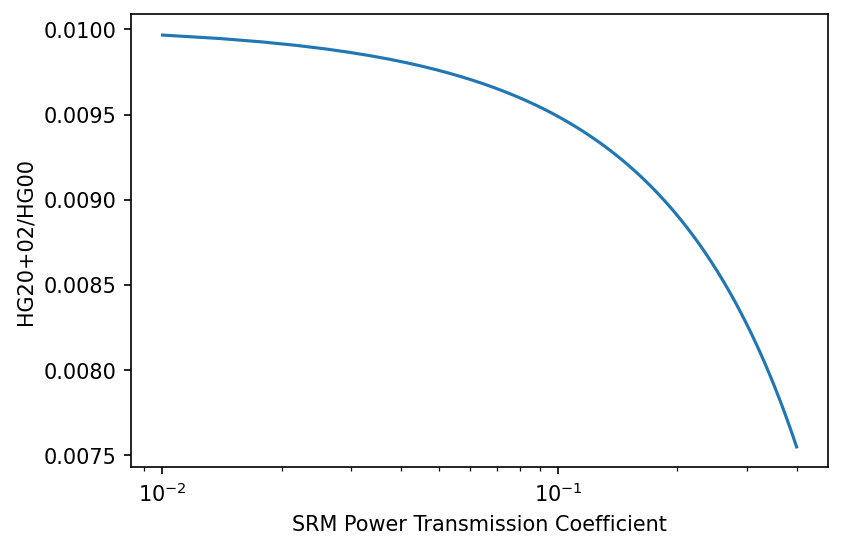

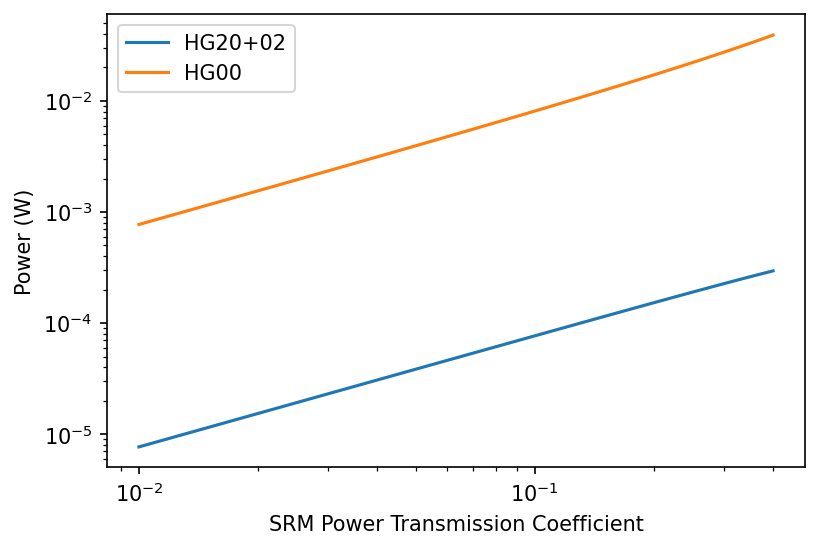

In [12]:
    
plt.figure(figsize = (6,4),dpi = 150)
plt.semilogx(SRM_T_experiement_out.x, (SRM_T_experiement_out['ad_HOM_2_y']**2 + SRM_T_experiement_out['ad_HOM_2_x']**2)/(SRM_T_experiement_out['p_out'] - SRM_T_experiement_out['p_out_hOM'] ))
#plt.semilogx(SRM_T_experiement_out_maxtem_16.x, (SRM_T_experiement_out_maxtem_16['ad_HOM_2_y']**2 + SRM_T_experiement_out_maxtem_16['ad_HOM_2_x']**2)/(SRM_T_experiement_out_maxtem_16['p_out'] - SRM_T_experiement_out_maxtem_16['p_out_hOM'] ))
plt.xlabel('SRM Power Transmission Coefficient')
plt.ylabel('HG20+02/HG00')
plt.savefig('sim_chapter_SRM_T_HG_ratio.eps')
plt.show()

plt.figure(figsize = (6,4),dpi = 150)
plt.loglog(SRM_T_experiement_out.x, (SRM_T_experiement_out['ad_HOM_2_y']**2 + SRM_T_experiement_out['ad_HOM_2_x']**2),label = 'HG20+02')
plt.loglog(SRM_T_experiement_out.x, (SRM_T_experiement_out['p_out'] - SRM_T_experiement_out['p_out_hOM'] ),label = 'HG00')
plt.xlabel('SRM Power Transmission Coefficient')
plt.legend()
plt.ylabel('Power (W)')
plt.show()

# Maxtem Experiment

In [13]:
SRM_maxtem_experiment = finesse.kat.deepcopy(michelson_with_FP_arms_and_src)

SRM_maxtem_experiment.maxtem = 2
maxtem = [2,4,6,8,10,12,14,16,18,20]
maxtem_out = []

SRM_maxtem_experiment.ETMx.phi = etm_tuning_rse
SRM_maxtem_experiment.ETMy.phi = -etm_tuning_rse

SRM_maxtem_experiment.SRM.phi = 90 #put arm cavity IFO in RSE mode

SRM_maxtem_experiment.parse('xaxis SR3 f lin {0} {1} 100'.format(x1,x2))

for i in maxtem:
    #uncomment to run, otherwise it slows down the script!
    michelson_with_FP_arms_and_src.maxtem = i
    maxtem_out.append(michelson_with_FP_arms_and_src.run())


Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis SR3 f lin 17.973
18.003 100'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:40:43.537446
Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

100% | ETA:  0:00:00 | Saving data                                             



Finished in 0.185505 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:40:43.723948


100% | ETA:  0:00:00 | Saving data                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 0.934033 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 14:40:44.657980


...

100% | ETA:  0:00:00 | Saving data                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 924.623 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:09:53.883072


 64% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 1478.77 seconds


100% | ETA:  0:00:00 | Saving data                                             

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


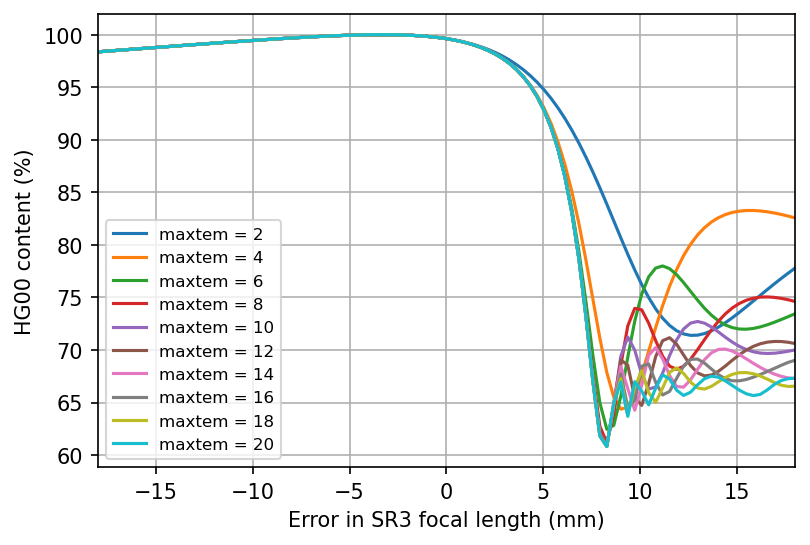

In [14]:
nom_value = nominal_sr3_f
plt.figure(figsize = figure_size,dpi = 150)
plt.plot(1e3*(maxtem_out[0].x-nom_value),100*(1-maxtem_out[0]['p_out_hOM']/maxtem_out[0]['p_out']),label = 'maxtem = 2')
plt.plot(1e3*(maxtem_out[1].x-nom_value),100*(1-maxtem_out[1]['p_out_hOM']/maxtem_out[1]['p_out']),label = 'maxtem = 4')
plt.plot(1e3*(maxtem_out[2].x-nom_value),100*(1-maxtem_out[2]['p_out_hOM']/maxtem_out[2]['p_out']),label = 'maxtem = 6')
plt.plot(1e3*(maxtem_out[3].x-nom_value),100*(1-maxtem_out[3]['p_out_hOM']/maxtem_out[3]['p_out']),label = 'maxtem = 8')
plt.plot(1e3*(maxtem_out[4].x-nom_value),100*(1-maxtem_out[4]['p_out_hOM']/maxtem_out[4]['p_out']),label = 'maxtem = 10')
plt.plot(1e3*(maxtem_out[5].x-nom_value),100*(1-maxtem_out[5]['p_out_hOM']/maxtem_out[5]['p_out']),label = 'maxtem = 12')
plt.plot(1e3*(maxtem_out[6].x-nom_value),100*(1-maxtem_out[6]['p_out_hOM']/maxtem_out[6]['p_out']),label = 'maxtem = 14')
plt.plot(1e3*(maxtem_out[7].x-nom_value),100*(1-maxtem_out[7]['p_out_hOM']/maxtem_out[7]['p_out']),label = 'maxtem = 16')
plt.plot(1e3*(maxtem_out[8].x-nom_value),100*(1-maxtem_out[8]['p_out_hOM']/maxtem_out[8]['p_out']),label = 'maxtem = 18')
plt.plot(1e3*(maxtem_out[9].x-nom_value),100*(1-maxtem_out[9]['p_out_hOM']/maxtem_out[9]['p_out']),label = 'maxtem = 20')

plt.legend(prop={'size': 8})
plt.xlabel('Error in SR3 focal length (mm)')
plt.ylabel('HG00 content (%)')
plt.xlim([-18,18])
plt.grid()
plt.savefig('sim_chapter_maxtem_experiment.eps',dpi = 150)
plt.show()

# Appendix A: Arm model
To find suitable numbers to use for the gauss command in the simulation of single bounce and locked arm beam measurements, the following simulation was run. It uses the same Y arm and beam splitter as the main simulation from the previous section, however it does not have an X arm or the SRC. Without the ```cav``` command, finesse will default to using a 2mm beam with its waist at z = 0 with respect to the the the node at the laser. The following beam parameters were found with a ```bp``` detector placed at the lasers node:

- $w_0 = 0.00864064287177005$ m
- $z = 1339.83530090614$ m

To figure out if the sign of z is correct, consider what happens if the beam parameter detector is moved 1m towards the cavity to ```bs_a```:

- $w_0 = 0.00864064287177005 $
- $z = 1338.83530090614$ m

$z$ increasing suggests moving from n1 to bs_a causes one to be closer to the waist. Intuitively, we know this is the case since the geometry of the cavity means the waist is within the cavity, and moving towards the cavity means you are moving towards the cavity waist. In otherwords, we know the beam should be getting smaller as we move from the laser to the cavity, which matches the behaviour seen here.

However, for some reason setting the beam parameter at the laser with the first set of numbers gives *terrible* mode matching. The simulation below investigates this. A photodiode which is masked from the TM00 mode 
``` 
pd HOM bs_d 
mask HOM 0 0 0
```
was placed at bs_d, which has the beam reflected from the arm cavity in it. The value of $z$ for the ```gauss``` was varied and the power incident on ```HOM``` was measured. To check that enough HOM were being used, the simulation was repeated with several ```maxtem``` commands. The results had a quadratic fitted to them, and the minimum was taken as the optimal value. I'm not sure if this is the true optimum value, since the rayleigh length of the laser beam was not investigated, but the values 

- $w_0 = 0.00864064287177005$ m
- $z = -1339.83683935$ m

give more than 99.99999% mode matching, which for my interests is pleanty. This looks really close to the first answer obtained, except with a minus sign.
 

In [16]:
arm_model_code = """ 
l l1 100 0 n1

maxtem 6

s space1 1 n1 bs_a

#################################################
bs BSfront 0.5 0.5 0 0 bs_a bs_b nBSi1 nBSi3
s BSsubstrate1 1p 1.45 nBSi1 nBSi2
s BSsubstrate2 1p 1.45 nBSi3 nBSi4
bs BSback1 0 1 0 0 nBSi2 dump bs_c dump
bs BSback2 0 1 0 0 nBSi4 dump bs_d dump

##################################################
## Y ARM

s s_bs_to_ITMy 4.8471 bs_b nITMyARa

#ITMy
m1 ITMyAR 1 0 $phi_ITMy nITMyARa nITMyARb
s sITMy_thickness 0.05 1.45 nITMyARb nITMyTLa
lens ITMyTL 50k nITMyTLa nITMyTLb
s sITMy_thickness2 0.05 1.45 nITMyTLb nITMyHRa
m1 ITMy 0.0148 0 $phi_ITMy nITMyHRa nITMyHRb
attr ITMy Rc -1934

s space_arm_y 3994.5 nITMyHRb nETMy 

m ETMy 1 0 $phi_ETMy nETMy dump
attr ETMy Rc 2245

cav army ETMy nETMy ITMy nITMyHRb

##################################################
#N.B these tunings don't represent how an IFO is kept on the dark fringe
const phi_ITMx 0# 0.000561571624295843
const phi_ITMy 0# -0.000561571624295843
const phi_ETMx 0.2135# 0.00179545319662242
const phi_ETMy -0.2135# -0.00184678655646107
const phi_BS 0
##################################################

bp laser_w0x x w0 n1
bp laser_w0y y w0 n1
bp laser_zx x z n1
bp laser_zy y z n1

bp bsa_w0x x w0 bs_a
bp bsa_w0y y w0 bs_a
bp bsa_zx x z bs_a
bp bsa_zy y z bs_a

pd HOM bs_d 
mask HOM 0 0 0 

beam beamshape bs_d

xaxis beamshape x lin -10 10 200 

#xaxis space1 L lin 0 3000 1000
#x2axis beamParaml1 zrx lin 1e-2 1000 100
#noxaxis

trace 8
"""

arm_model = finesse.kat()
arm_model.parse(arm_model_code)
arm_out = arm_model.run()
arm_model.parse('gauss beamParaml1 l1 n1 0.00864064287177005 -1339.83683935')
arm_out_2 = arm_model.run()

arm_model.parse('maxtem 2')
arm_model.parse('xaxis beamParaml1 zx lin -1500 -1200 1000')
arm_out_3 = arm_model.run()
arm_model.parse('maxtem 4')
arm_out_4 = arm_model.run()
arm_model.parse('maxtem 6')
arm_out_5 = arm_model.run()

Parsing `mask HOM 0 0 0` into pykat object not implemented yet, added as extra line.
--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:34:47.006093
Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 0.120677 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:34:47.127767


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 0.150597 seconds

Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis beamParaml1 zx lin
-1500 -1200 1000'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:34:47.280360


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 0.78889 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:34:48.070247


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 4.8231 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:34:52.893350


 95% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 21.9872 seconds


100% | ETA:  0:00:00 | Calculating                                             


w0x at n1 = 0.00864064287177005
w0y at n1 = 0.00864064287177005
zx at n1= 1339.83530090614
zy at n1= 1339.83530090614


w0x at bs_a = 0.00864064287177005
w0y at bs_a = 0.00864064287177005
zx at bs_a= 1338.83530090614
zy at bs_a= 1338.83530090614

min at [-1339.83683935]m
with HOM power = [6.91679428e-06] W
Mode matching with this solution is [99.99999308] W
0.0
3.04398572065124e-10


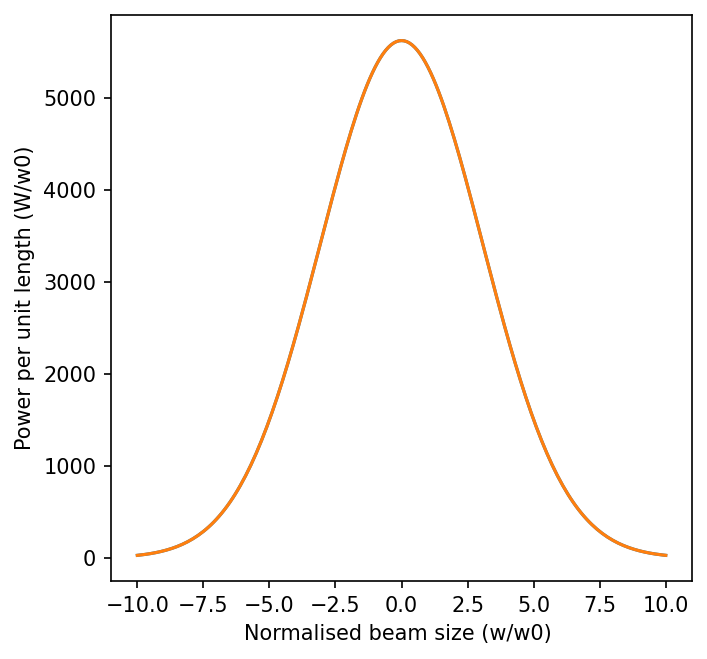

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


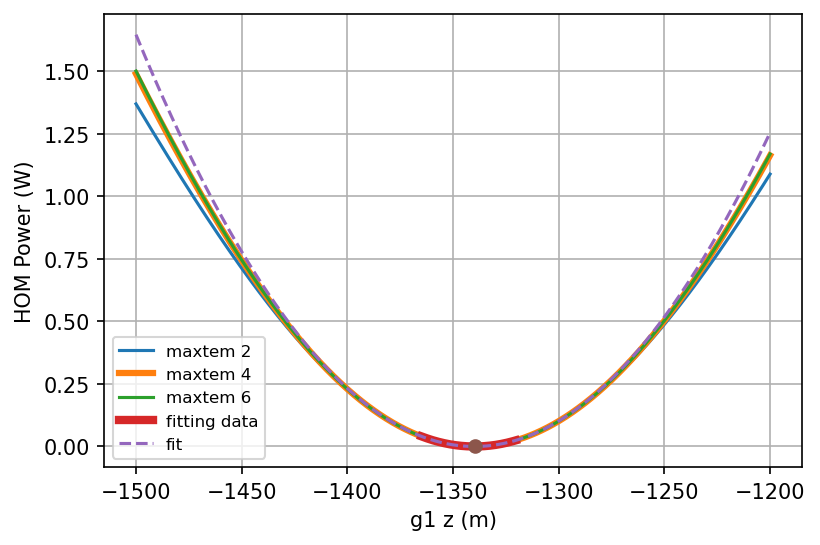

In [26]:
print("""
w0x at n1 = {0}
w0y at n1 = {1}
zx at n1= {2}
zy at n1= {3}
""".format(arm_out['laser_w0x'][0],arm_out['laser_w0y'][0],arm_out['laser_zx'][0],arm_out['laser_zy'][0]))
print("""
w0x at bs_a = {0}
w0y at bs_a = {1}
zx at bs_a= {2}
zy at bs_a= {3}
""".format(arm_out['bsa_w0x'][0],arm_out['bsa_w0y'][0],arm_out['bsa_zx'][0],arm_out['bsa_zy'][0]))

xdata = arm_out_5.x[450:600]
ydata = arm_out_5['HOM'][450:600]

poly_coef = np.polyfit(xdata,ydata,2)
yfit = np.poly1d(poly_coef)
crit = yfit.deriv().r
r_crit = crit[crit.imag==0].real
test = yfit.deriv(2)(r_crit) 

x_min = r_crit[test>0]
y_min = yfit(x_min)

print('min at {0}m'.format(x_min))
print('with HOM power = {0} W'.format(y_min))
print('Mode matching with this solution is {0} W'.format((1-y_min/100)*100 ))


print(arm_out['HOM'][0])
print(arm_out_2['HOM'][0])
#print(arm_out._KatRun__stdout)
plt.figure(figsize = (5,5),dpi = 150)
plt.plot(arm_out.x,arm_out['beamshape'])
plt.plot(arm_out_2.x,arm_out_2['beamshape'])
plt.xlabel('Normalised beam size (w/w0) ')
plt.ylabel('Power per unit length (W/w0)')
plt.show()

plt.figure(figsize = (6,4),dpi = 150)
plt.plot(arm_out_3.x,arm_out_3['HOM'],label = 'maxtem 2')
plt.plot(arm_out_4.x,arm_out_4['HOM'],linewidth = 3,label = 'maxtem 4')
plt.plot(arm_out_5.x,arm_out_5['HOM'],label = 'maxtem 6')
plt.plot(xdata,ydata,linewidth = 4, label = 'fitting data')
plt.plot(arm_out_5.x,yfit(arm_out_5.x),linestyle = '--',label = 'fit')
plt.plot( x_min, y_min, 'o' )
plt.xlabel('g1 z (m)')
plt.ylabel('HOM Power (W)')
plt.legend(prop={'size': 8})
plt.grid()
plt.savefig('sim_chapter_gauss_command_fitting.eps')
plt.show()

# Appendix B
This was deemed important enought to become a main part of the code. This was for finding the tunings for all the simulations. It became hard to manage being a seperate code block, so the functionality was implemented into the main part of the code (instead of hard coding numbers in!).
# Appendix C
This simulation is the same as the one above, except it has no signal recycling cavity. To set the reflectivity of the IFO to be correct (does that even make sense?), the src was removed.

In [18]:
michelson_with_FP_arms = """ 
l l1 5M 0 n1
gauss beamParaml1 l1 n1 0.00864064287177005 -1339.83683935 

maxtem 6

s space1 1 n1 bs_a

#################################################
#bs beam_splitter 0.5 0.5 $phi_BS 0 bs_a bs_b bs_c bs_d
#bs beam_splitter 0.5 0.5 $phi_BS 0 bs_a bs_b bs_c bs_d

bs BSfront 0.5 0.5 0 0 bs_a bs_b nBSi1 nBSi3
s BSsubstrate1 1p 1.45 nBSi1 nBSi2
s BSsubstrate2 1p 1.45 nBSi3 nBSi4
bs BSback1 0 1 0 0 nBSi2 dump bs_c dump
bs BSback2 0 1 0 0 nBSi4 dump bs_d dump
 


##################################################
## Y ARM

s s_bs_to_ITMy 4.8471 bs_b nITMyARa

#ITMy
m1 ITMyAR 1 0 $phi_ITMy nITMyARa nITMyARb
s sITMy_thickness 0.05 1.45 nITMyARb nITMyTLa
lens ITMyTL 50k nITMyTLa nITMyTLb
s sITMy_thickness2 0.05 1.45 nITMyTLb nITMyHRa
m1 ITMy 0.0148 0 $phi_ITMy nITMyHRa nITMyHRb
attr ITMy Rc -1934

s space_arm_y 3994.5 nITMyHRb nETMy 

m ETMy 1 0 $phi_ETMy nETMy dump
attr ETMy Rc 2245

#cav army ETMy nETMy ITMy nITMyHRb

##################################################

## X ARM

s s_bs_to_ITMx 4.8471 bs_c nITMxARa

#ITMx
m1 ITMxAR 1 0 $phi_ITMx nITMxARa nITMxARb
s sITMx_thickness 0.05 1.45 nITMxARb nITMxTLa
lens ITMxTL 50k nITMxTLa nITMxTLb
s sITMx_thickness2 0.05 1.45 nITMxTLb nITMxHRa
m1 ITMx 0.0148 0 $phi_ITMx nITMxHRa nITMxHRb
attr ITMx Rc -1934

s space_arm_x 3994.5 nITMxHRb nETMx

m ETMx 1 0 $phi_ETMx nETMx dump
attr ETMx Rc 2245

#cav armx ETMx nETMx ITMx nITMxHRb

##################################################
#N.B these tunings don't represent how an IFO is kept on the dark fringe
const phi_ITMx 0 
const phi_ITMy 0
const phi_ETMx 0 
const phi_ETMy 0
const phi_BS 0  
##################################################

bp laser_w x w0 n1
bp laser_z x z n1

beam ITMy_refl nITMyHRa
beam ITMy_refl nITMyHRa

bp ITMy_refl_w x w nITMyHRa
bp ITMx_refl_w x w nITMxHRa

pd p_in bs_a*
pd p_ref bs_a

pd p_out bs_d

pd p_out_hOM bs_d
mask p_out_hOM 0 0 0

ad ad_HOM_2_y 2 0 0 bs_d
ad ad_HOM_2_x 0 2 0 bs_d

trace 64
phase 3

#retrace

#yaxis abs
"""

appendix_c = finesse.kat()
appendix_c.parse(michelson_with_FP_arms)

appendix_c.s_bs_to_ITMx.L = 4.8471 #+ 80e-3 #ref D0902838

appendix_c.ITMx.phi = 0# 0.000561571624295843
appendix_c.ITMy.phi =  0#-0.000561571624295843
appendix_c.ITMxAR.phi = 0# 0.000561571624295843
appendix_c.ITMyAR.phi =  0# -0.000561571624295843
appendix_c.ETMy.phi =  0 #0.00179545319662242
appendix_c.ETMy.phi =  0 #-0.00184678655646107

ITM_T = 0.0148
ITM_L = 10e-6
ITM_R = 1 - ITM_T - ITM_L

ETM_T = 0
ETM_L = 10e-6
ETM_R = 1 - ETM_T - ETM_L

appendix_c.ITMx.R = ITM_R
appendix_c.ITMx.T = ITM_T
appendix_c.ITMx.L = ITM_L

appendix_c.ITMy.R = ITM_R
appendix_c.ITMy.T = ITM_T
appendix_c.ITMy.L = ITM_L

appendix_c.parse("""
maxtem 6
xaxis ETMx phi lin -0.00001 0.00001 1000
func ETMy_phi = (-1)*$x1
put ETMy phi ETMy_phi
""")

appendix_c_out = appendix_c.run()
appendix_c.parse('xaxis ETMx phi lin -100 100 1000')
appendix_c_out_2 = appendix_c.run()

appendix_c.ITMx.R = 1
appendix_c.ITMx.T = 0
appendix_c.ITMx.L = 0

appendix_c.ITMy.R = 1
appendix_c.ITMy.T = 0
appendix_c.ITMy.L = 0

appendix_c.parse("""
xaxis ITMx phi lin 0 360 1000
func ITMy_phi = (-1)*$x1
put ITMy phi ITMy_phi
""")

appendix_c_out_3 = appendix_c.run()

appendix_c.parse('xaxis ITMx phi lin -0.003 0.003 1000')
appendix_c_out_4 = appendix_c.run()



Removed existing object 'ITMy_refl' of type <class
'pykat.detectors.pykat.detectors.beam_121'> to add line 'beam
ITMy_refl nITMyHRa'

Parsing `mask p_out_hOM 0 0 0` into pykat object not implemented yet, added as extra line.
--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:35:16.292804


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 6.40832 seconds

Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis ETMx phi lin -100
100 1000'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:35:22.704112


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 4.70852 seconds

Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis ITMx phi lin 0 360
1000'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:35:27.416618


100% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 4.65648 seconds

Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis ITMx phi lin -0.003
0.003 1000'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:35:32.075094


 95% | ETA:  0:00:00 | Calculating                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 5.2632 seconds


100% | ETA:  0:00:00 | Calculating                                             

detuning of each ETM = +- 8.28e-06
Differential detuning ETM = 1.656e-05
detuning of each ITM = +- -0.00222
Differential detuning ITM = -0.00444


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


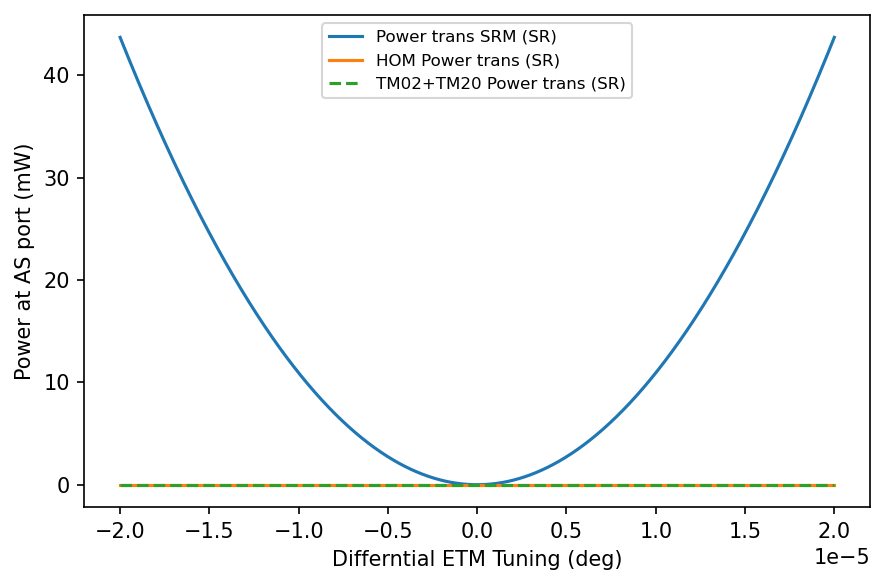

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


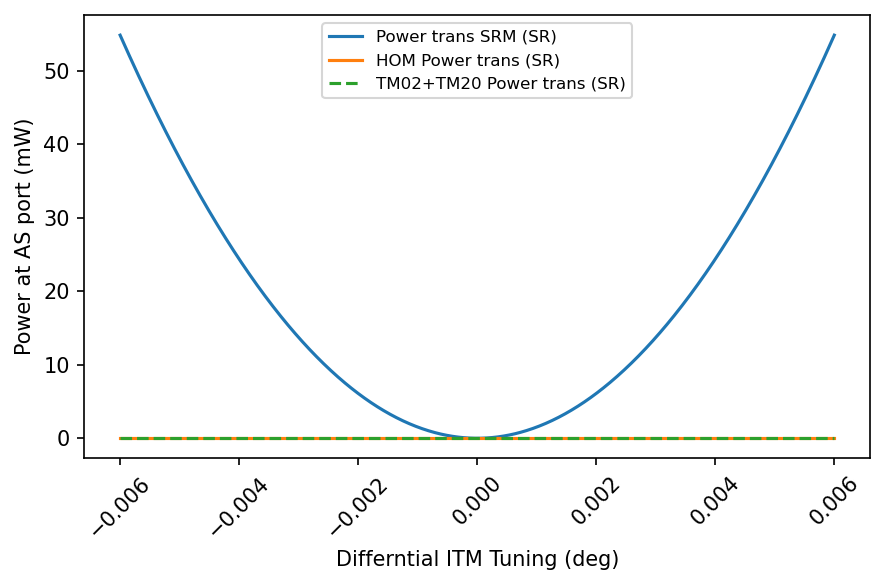

In [19]:

idx = (np.abs(appendix_c_out['p_out'] - 30e-3)).argmin()
print('detuning of each ETM = +- {0}'.format(appendix_c_out.x[idx]))
print('Differential detuning ETM = {0}'.format(2*appendix_c_out.x[idx]))

idx = (np.abs(appendix_c_out_4['p_out'] - 30e-3)).argmin()
print('detuning of each ITM = +- {0}'.format(appendix_c_out_4.x[idx]))
print('Differential detuning ITM = {0}'.format(2*appendix_c_out_4.x[idx]))

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(2*appendix_c_out.x,1000*appendix_c_out['p_out'],label = 'Power trans SRM (SR)')
plt.plot(2*appendix_c_out.x,1000*appendix_c_out['p_out_hOM'],label = 'HOM Power trans (SR)')
plt.plot(2*appendix_c_out.x,1000*appendix_c_out['ad_HOM_2_y']**2+ appendix_c_out['ad_HOM_2_x']**2,linestyle = '--',label = 'TM02+TM20 Power trans (SR)')
plt.legend(prop={'size': 8})
plt.xlabel('Differntial ETM Tuning (deg)')
plt.ylabel('Power at AS port (mW)')
#plt.ylim([0,50e-3])
plt.tight_layout()
plt.savefig('sim_chapter_Zoom_in_ETM_tuning.eps')
plt.show()

#plt.figure(figsize = (5,5),dpi = 150)
#plt.semilogy(2*appendix_c_out_2.x,appendix_c_out_2['p_out'],label = 'Power trans SRM (SR)')
#plt.semilogy(2*appendix_c_out_2.x,appendix_c_out_2['p_out_hOM'],label = 'HOM Power trans (SR)')
#plt.semilogy(2*appendix_c_out_2.x,appendix_c_out_2['ad_HOM_2_y']**2+ appendix_c_out_2['ad_HOM_2_x']**2,label = 'TM02+TM20 Power trans (SR)')
#plt.legend(prop={'size': 8})
#plt.xlabel('Differntial ETM Tuning (deg)')
#plt.ylabel('Power at AS port (W)')
#plt.ylim(5e-7,5e6)
#plt.savefig('Zoom_out_ETM_tuning.pdf')
#plt.show()

theory = 5e6*np.cos(appendix_c_out_3.x*2 * np.pi/180 + np.pi/2)**2

#plt.figure(figsize = (5,5),dpi = 150)
#plt.plot(2*appendix_c_out_3.x,appendix_c_out_3['p_out'],label = 'Power trans SRM (SR)')
#plt.plot(2*appendix_c_out_3.x,theory)
#plt.plot(2*appendix_c_out_3.x,appendix_c_out_3['p_out_hOM'],label = 'HOM Power trans (SR)')
#plt.plot(2*appendix_c_out_3.x,appendix_c_out_3['ad_HOM_2_y']**2+ appendix_c_out_3['ad_HOM_2_x']**2,label = 'TM02+TM20 Power trans (SR)')
#plt.legend(prop={'size': 8})
#plt.xlabel('Differntial ITM Tuning (deg)')
#plt.ylabel('Power at AS port (W)')
#plt.savefig('Zoom_out_ITM_tuning.pdf')
#plt.show()

plt.figure(figsize = figure_size,dpi = 150)
plt.plot(2*appendix_c_out_4.x,1000*appendix_c_out_4['p_out'],label = 'Power trans SRM (SR)')
plt.plot(2*appendix_c_out_4.x,1000*appendix_c_out_4['p_out_hOM'],label = 'HOM Power trans (SR)')
plt.plot(2*appendix_c_out_4.x,1000*appendix_c_out_4['ad_HOM_2_y']**2+ appendix_c_out_4['ad_HOM_2_x']**2,linestyle = '--',label = 'TM02+TM20 Power trans (SR)')
plt.legend(prop={'size': 8})
plt.xlabel('Differntial ITM Tuning (deg)')
plt.ylabel('Power at AS port (mW)')
plt.xticks(rotation = 45)
#plt.xlim([-0.006,+0.006])
#plt.ylim([0,50e-3])
plt.tight_layout()
plt.savefig('sim_chapter_Zoom_in_ITM_tuning.eps')
plt.show()

# Appendix D: Nominal SRC
This simulation uses design values for the signal recyling cavity.w

In [20]:
appendix_d = finesse.kat()
appendix_d.parse(""" 
l l1 5M 0 n1
gauss beamParaml1 l1 n1 0.00864064287177005 -1339.83683935 

maxtem 6

s space1 1 n1 bs_a

#################################################
bs beam_splitter 0.5 0.5 $phi_BS 0 bs_a bs_b bs_c bs_d

##################################################
## Y ARM

s s_bs_to_ITMy 4.847 bs_b nITMyARa

#ITMy
m1 ITMyAR 1 0 $phi_ITMy nITMyARa nITMyARb
s sITMy_thickness 0.05 1.45 nITMyARb nITMyTLa
lens ITMyTL 50k nITMyTLa nITMyTLb
s sITMy_thickness2 0.05 1.45 nITMyTLb nITMyHRa
m1 ITMy 0.0148 0 $phi_ITMy nITMyHRa nITMyHRb
attr ITMy Rc -1934

s space_arm_y 3994.5 nITMyHRb nETMy 

m ETMy 1 0 $phi_ETMy nETMy dump
attr ETMy Rc 2245

#cav army ETMy nETMy ITMy nITMyHRb

##################################################

## X ARM

s s_bs_to_ITMx 4.847 bs_c nITMxARa

#ITMx
m1 ITMxAR 1 0 $phi_ITMx nITMxARa nITMxARb
s sITMx_thickness 0.05 1.45 nITMxARb nITMxTLa
lens ITMxTL 50k nITMxTLa nITMxTLb
s sITMx_thickness2 0.05 1.45 nITMxTLb nITMxHRa
m1 ITMx 0.0148 0 $phi_ITMx nITMxHRa nITMxHRb
attr ITMx Rc -1934

s space_arm_x 3994.5 nITMxHRb nETMx

m ETMx 1 0 $phi_ETMx nETMx dump
attr ETMx Rc 2245

#cav armx ETMx nETMx ITMx nITMxHRb

##################################################

## SRC 

s bs_to_SR3 19.368 bs_d nSR3a

lens SR3 18 nSR3a nSR3b  

s SR3_to_SR2 15.4607 nSR3b nSR2a

lens SR2 -3.2135 nSR2a nSR2b

s SR2_to_SRM 15.726 nSR2b nSRMa

m1 SRM 0.324 0 0 nSRMa nSRMb
s SRM_substrate 0.075 1.45 nSRMb nSRMc
m SRM_AR 0 1 0 nSRMc nSRMd
attr SRM Rc -5.6938

#cav src ITMx nITMxHRa SRM nSRMa

##################################################
#N.B these tunings don't represent how an IFO is kept on the dark fringe
const phi_ITMx 0 
const phi_ITMy 0
const phi_ETMx 0 
const phi_ETMy 0
const phi_BS 0  
##################################################

beam SRM_trans nSRMd
#mask SRM_trans 0 0 0

bp SRM_trans_w0 x w0 nSRMd
bp SRM_trans_w x w nSRMd
bp SRM_trans_r x r nSRMd

bp laser_w x w0 n1
bp laser_z x z n1

beam ITMy_refl nITMyHRa
beam ITMy_refl nITMyHRa

bp ITMy_refl_w x w nITMyHRa
bp ITMx_refl_w x w nITMxHRa

pd p_in bs_a*
pd p_ref bs_a

pd p_out nSRMd

pd p_out_hOM nSRMc
mask p_out_hOM 0 0 0

ad ad_HOM_2_y 2 0 0 nSRMd
ad ad_HOM_2_x 0 2 0 nSRMd

gouy src_gouy y sITMx_thickness sITMx_thickness2 s_bs_to_ITMx bs_to_SR3 SR3_to_SR2 SR2_to_SRM

trace 64
phase 2

xaxis SRM_trans x lin -10 10 200 

#retrace""")
out_d = appendix_d.run()

print('beam width at ITM = {0:.2f} mm.'.format(out_d['ITMy_refl_w'][0]*1000))
print('beam width at SRM = {0:.2f} mm.'.format(out_d['SRM_trans_w'][0]*1000))
print('beam RoC at SRM = {0:.2f} m.'.format(out_d['SRM_trans_r'][0]))
print('Power in:  {0:.6f}'.format(out_d['p_in'][0]))
print('Power ref:  {0:.6f}'.format(out_d['p_ref'][0]))
print('Power out:  {0:.6f}'.format(out_d['p_out'][0]))
print('HOM power out:  {0:.6e}'.format(out_d['p_out_hOM'][0]))
print('HOM % :  {0:.6f}'.format(100*out_d['p_out_hOM'][0]/out_d['p_out'][0]))
print('Gouy Phase accumulated within SRC = {0}'.format(out_d['src_gouy'][0]))


Removed existing object 'ITMy_refl' of type <class
'pykat.detectors.pykat.detectors.beam_133'> to add line 'beam
ITMy_refl nITMyHRa'

Parsing `mask p_out_hOM 0 0 0` into pykat object not implemented yet, added as extra line.
--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:35:38.975966
Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 0.204483 seconds
beam width at ITM = 52.99 mm.
beam width at SRM = 1.95 mm.
beam RoC at SRM = -3.73 m.
Power in:  5000000.000000
Power ref:  3379999.859813
Power out:  1620000.000000
HOM power out:  0.000000e+00
HOM % :  0.000000
Gouy Phase accumulated within SRC = 20.034538031517


100% | ETA:  0:00:00 | Calculating                                             

# RoC error and Gouy Phase

In [21]:
print('xaxis SR2 f lin {0} {1} 100'.format(-3.203-9e-3,-3.203+9e-3))
print('xaxis SR2 f lin {0} {1} 100'.format(17.985-18e-3,17.985+18e-3))

xaxis SR2 f lin -3.2119999999999997 -3.194 100
xaxis SR2 f lin 17.967 18.003 100


In [22]:
gouy_phase_investigation_code = """ 
l l1 5M 0 n1
gauss beamParaml1 l1 n1 0.00864064287177005 -1339.83683935 

maxtem 1

s space1 1 n1 bs_a

#################################################
bs BSfront 0.5 0.5 0 0 bs_a bs_b nBSi1 nBSi3
s BSsubstrate1 1p 1.45 nBSi1 nBSi2
s BSsubstrate2 1p 1.45 nBSi3 nBSi4
bs BSback1 0 1 0 0 nBSi2 dump bs_c dump
bs BSback2 0 1 0 0 nBSi4 dump bs_d dump
##################################################
## Y ARM

s s_bs_to_ITMy 4.8471 bs_b nITMyARa

#ITMy
m1 ITMyAR 1 0 $phi_ITMy nITMyARa nITMyARb
s sITMy_thickness 0.05 1.45 nITMyARb nITMyTLa
lens ITMyTL 50k nITMyTLa nITMyTLb
s sITMy_thickness2 0.05 1.45 nITMyTLb nITMyHRa
m1 ITMy 0.0148 10u $phi_ITMy nITMyHRa nITMyHRb
attr ITMy Rc -1934

s space_arm_y 3994.5 nITMyHRb nETMy 

m1 ETMy 0 10u $phi_ETMy nETMy dump
attr ETMy Rc 2245

cav army ETMy nETMy ITMy nITMyHRb

##################################################

## X ARM

s s_bs_to_ITMx 4.8471 bs_c nITMxARa

#ITMx
m1 ITMxAR 1 0 $phi_ITMx nITMxARa nITMxARb
s sITMx_thickness 0.05 1.45 nITMxARb nITMxTLa
lens ITMxTL 50k nITMxTLa nITMxTLb
s sITMx_thickness2 0.05 1.45 nITMxTLb nITMxHRa
m1 ITMx 0.0148 10u $phi_ITMx nITMxHRa nITMxHRb
attr ITMx Rc -1934

s space_arm_x 3994.5 nITMxHRb nETMx

m1 ETMx 0 10u $phi_ETMx nETMx dump
attr ETMx Rc 2245

cav armx ETMx nETMx ITMx nITMxHRb

##################################################

## SRC 

s bs_to_SR3 19.3659 bs_d nSR3a

lens SR3 17.985 nSR3a nSR3b  

s SR3_to_SR2 15.4435 nSR3b nSR2a

lens SR2 -3.203 nSR2a nSR2b

s SR2_to_SRM 15.7562 nSR2b nSRMa

m1 SRM 0.324 0 0 nSRMa nSRMb
s SRM_substrate 0.07 1.45 nSRMb nSRMc
m SRM_AR 0 1 0 nSRMc nSRMd
attr SRM Rc -5.673

#cav src ITMx nITMxHRa SRM nSRMa

##################################################
#N.B these tunings don't represent how an IFO is kept on the dark fringe
const phi_ITMx 0 
const phi_ITMy 0
const phi_ETMx 0 
const phi_ETMy 0
const phi_BS 0  
##################################################

beam SRM_trans nSRMd

bp SRM_trans_w0 x w0 nSRMd
bp SRM_trans_w x w nSRMd
bp SRM_trans_r x r nSRMd

gouy src_gouy y sITMx_thickness sITMx_thickness2 s_bs_to_ITMx bs_to_SR3 SR3_to_SR2 SR2_to_SRM

trace 64
phase 2

#xaxis SR2 f lin -3.212 -3.194 100
#x2axis SR3 f lin 17.967 18.003 100 
"""

gouy_phase_investigation = finesse.kat()

gouy_phase_investigation.parse(gouy_phase_investigation_code)
gouy_phase_investigation.ITMyTL.f = 50e3#25e3
gouy_phase_investigation.ITMxTL.f = 50e3#25e3
gouy_phase_investigation.parse("""
xaxis SR2 f lin -3.212 -3.194 100
x2axis SR3 f lin 17.967 18.003 100 
""")

gouy_phase_out = gouy_phase_investigation.run()

#################################

gouy_phase_investigation_code_z = gouy_phase_investigation_code
gouy_phase_investigation_z = finesse.kat()

gouy_phase_investigation_z.parse(gouy_phase_investigation_code_z)
gouy_phase_investigation_z.parse('xaxis SR3_to_SR2 L lin 15.4335 15.4535 200')

gouy_phase_out_z = gouy_phase_investigation_z.run()
gouy_phase_investigation_z.parse('xaxis SR2_to_SRM L lin 15.7462 15.7662 200')
gouy_phase_out_z1 = gouy_phase_investigation_z.run()

gouy_phase_investigation_TL = finesse.kat.deepcopy(gouy_phase_investigation_z)
gouy_phase_investigation_TL.parse("""

xaxis ITMyTL f lin 10k 75k 100
put ITMxTL f $x1
""")
gouy_phase_out_TL = gouy_phase_investigation_TL.run()

C:\anaconda3\envs\finesse\lib\site-packages\pykat\finesse.py:2114: UserWarning: 'KatRun2D' does not have attribute called 'katPath'
  r.katPath = kat_exec


--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:35:39.284245


100% | ETA:  0:00:00 | Saving data                                             

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe


C:\anaconda3\envs\finesse\lib\site-packages\pykat\finesse.py:2345: UserWarning: 'KatRun2D' does not have attribute called 'save_output'
  r.save_output = save_output
C:\anaconda3\envs\finesse\lib\site-packages\pykat\finesse.py:2362: UserWarning: 'KatRun2D' does not have attribute called 'save_input'
  r.save_input = save_kat
100% | ETA:  0:00:00 | Calculating                                             


Finished in 3.2206 seconds
--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:35:42.540745
Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 0.106715 seconds

Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis SR2_to_SRM L lin
15.7462 15.7662 200'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:35:42.649455


  0% | ETA:  --:--:-- | Calculating                                            

Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 0.123671 seconds

Removed existing object 'xaxis' of type <class
'pykat.commands.xaxis'> to add line 'xaxis ITMyTL f lin 10k
75k 100'

--------------------------------------------------------------
Running kat - Started at 2020-08-20 15:35:42.829972
Used Finesse None at C:\anaconda3\envs\finesse\Library\bin\kat.exe

Finished in 0.111704 seconds


100% | ETA:  0:00:00 | Saving data                                             

In [23]:
sr3_vals = []
sr2_vals = []

for idx,sr2_idx in enumerate(gouy_phase_out.x):
    for idy,sr3_idy in enumerate(gouy_phase_out.y):
        if( np.abs(21.3 - gouy_phase_out['src_gouy'][idy,idx]) < 0.01):
            sr2_vals.append(sr2_idx)
            sr3_vals.append(sr3_idy)
            



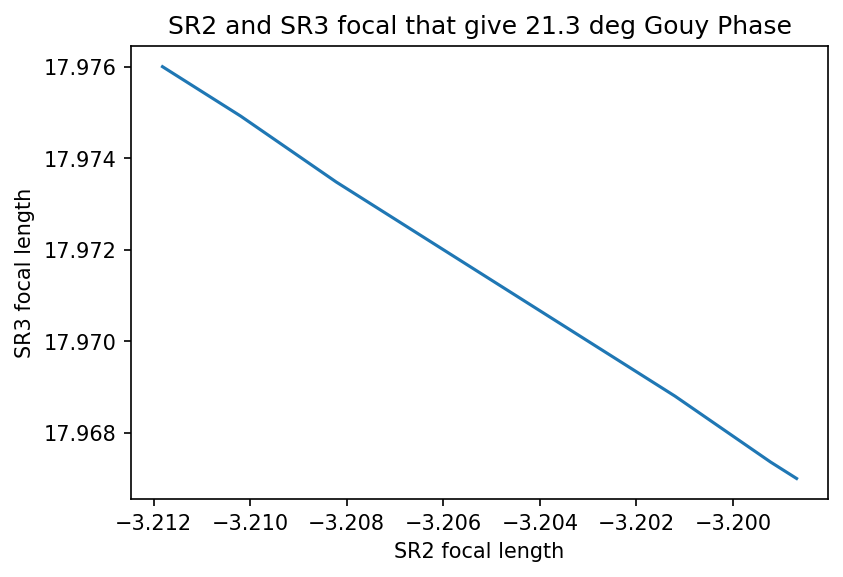

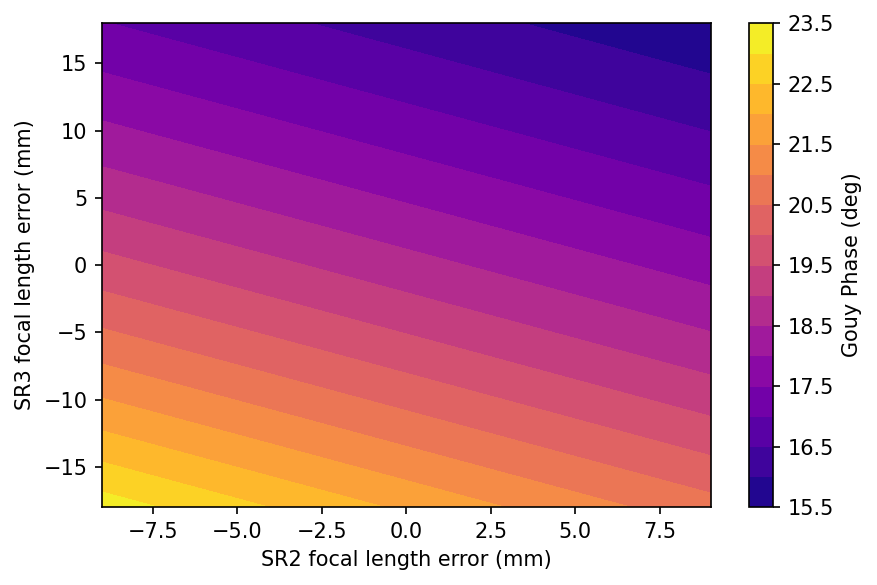

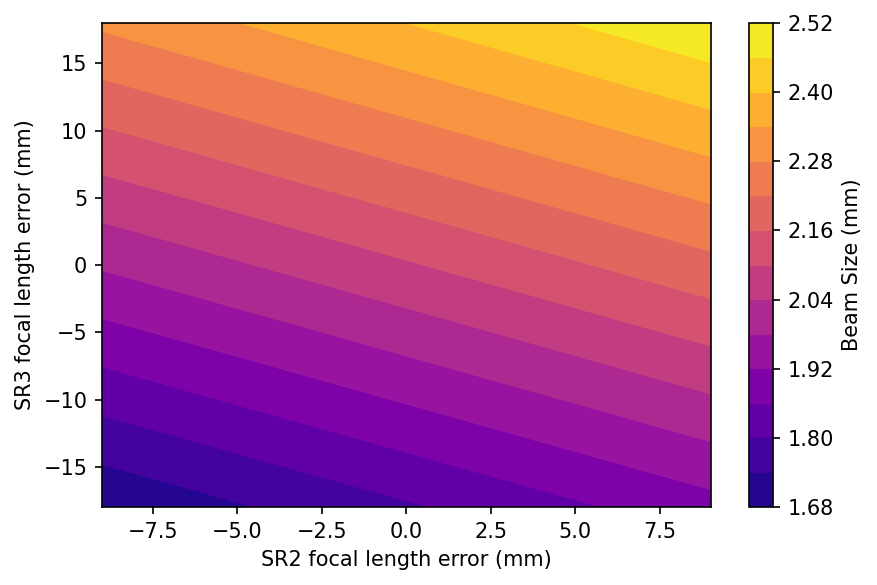

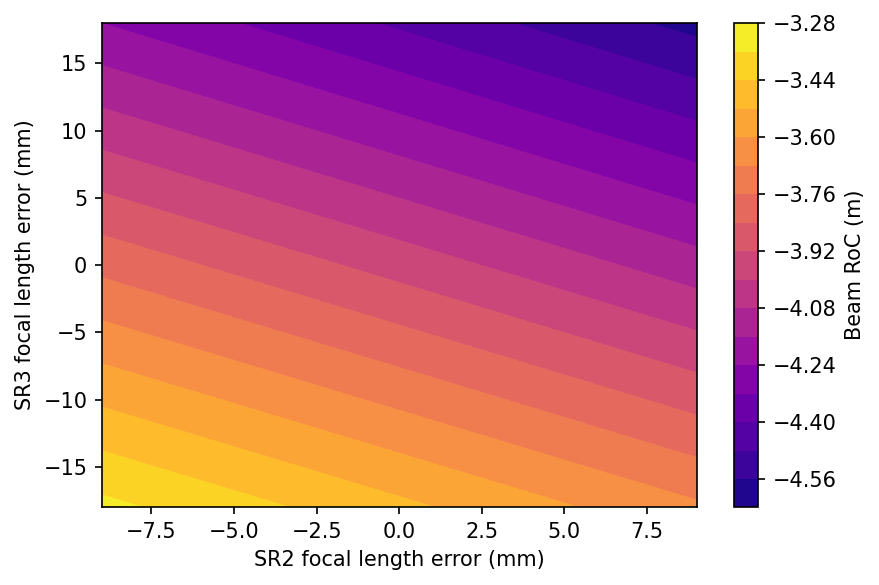

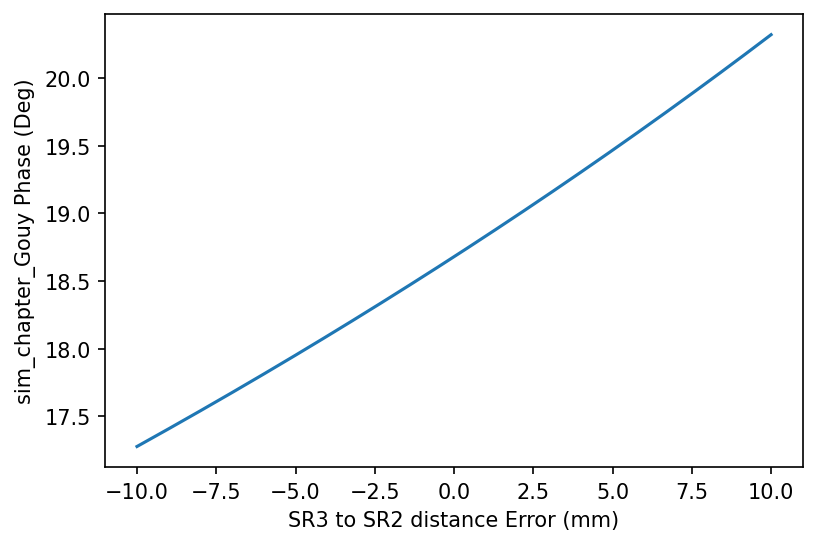

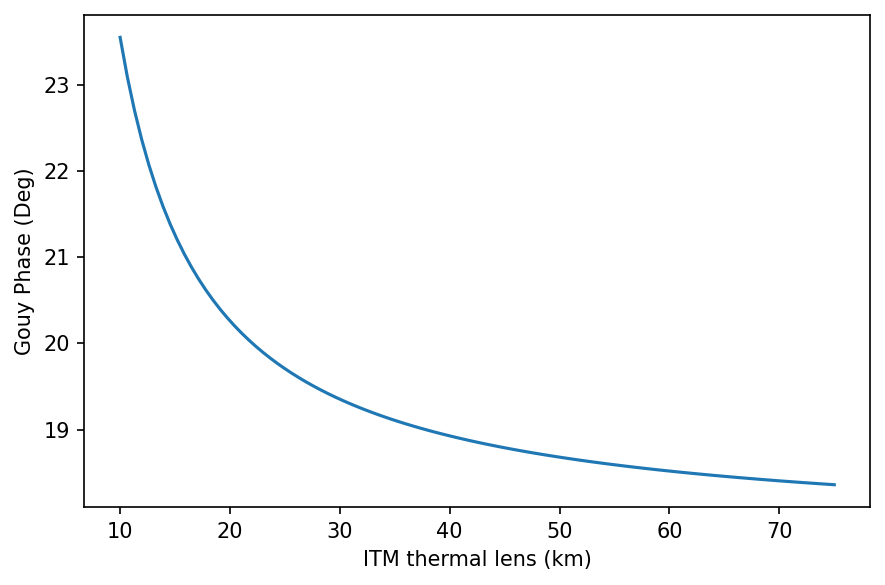

In [24]:

plt.figure(figsize = (6,4),dpi = 150)
plt.plot(sr2_vals,sr3_vals)
plt.title('SR2 and SR3 focal that give 21.3 deg Gouy Phase')
plt.xlabel('SR2 focal length')
plt.ylabel('SR3 focal length')
plt.show()

colour_map = 'plasma'

plt.figure(1,figsize = (6,4),dpi = 150)
plt.contourf(1e3*(gouy_phase_out.x+3.203),1e3*(gouy_phase_out.y-17.985),gouy_phase_out['src_gouy'],levels = 15,cmap = colour_map)
cbar = plt.colorbar()
ax = plt.gca()
cbar.set_label('Gouy Phase (deg)')
plt.xlabel('SR2 focal length error (mm)')
plt.ylabel('SR3 focal length error (mm)')
plt.tight_layout()
plt.savefig('sim_chapter_gouy_phase_sr2_sr3.eps')
plt.savefig('sim_chapter_gouy_phase_sr2_sr3.png')
plt.show()


plt.figure(2,figsize = (6,4),dpi = 150)
plt.contourf(1e3*(gouy_phase_out.x+3.203),1e3*(gouy_phase_out.y-17.985),gouy_phase_out['SRM_trans_w']*1e3,levels = 15,cmap = colour_map)
cbar = plt.colorbar()
ax = plt.gca()
cbar.set_label('Beam Size (mm)')
plt.xlabel('SR2 focal length error (mm)')
plt.ylabel('SR3 focal length error (mm)')
plt.tight_layout()
plt.savefig('sim_chapter_beam_size_sr2_sr3.eps')
plt.savefig('sim_chapter_beam_size_sr2_sr3.png')
plt.show()


plt.figure(figsize = (6,4),dpi = 150)
plt.contourf(1e3*(gouy_phase_out.x+3.203),1e3*(gouy_phase_out.y-17.985),gouy_phase_out['SRM_trans_r'],levels = 15,cmap = colour_map)
cbar = plt.colorbar()
cbar.set_label('Beam RoC (m)')
ax = plt.gca()
plt.xlabel('SR2 focal length error (mm)')
plt.ylabel('SR3 focal length error (mm)')
plt.tight_layout()
plt.savefig('sim_chapter_beam_roc_sr2_sr3.eps')
plt.savefig('sim_chapter_beam_roc_sr2_sr3.png')
plt.show()

plt.figure(figsize = (6,4),dpi = 150)
plt.plot((gouy_phase_out_z.x - 15.4435)*1e3, gouy_phase_out_z['src_gouy'])
plt.xlabel('SR3 to SR2 distance Error (mm)')
plt.ylabel('sim_chapter_Gouy Phase (Deg)')
plt.savefig('sim_chapter_SR3_SR2_z_error.eps')
plt.show()

plt.figure(figsize = (6,4),dpi = 150)
plt.plot(gouy_phase_out_TL.x/1e3, gouy_phase_out_TL['src_gouy'])
plt.xlabel('ITM thermal lens (km)')
plt.ylabel('Gouy Phase (Deg)')
plt.tight_layout()
plt.savefig('sim_chapter_ITM_TL.png')
plt.savefig('sim_chapter_ITM_TL.eps')
plt.show()


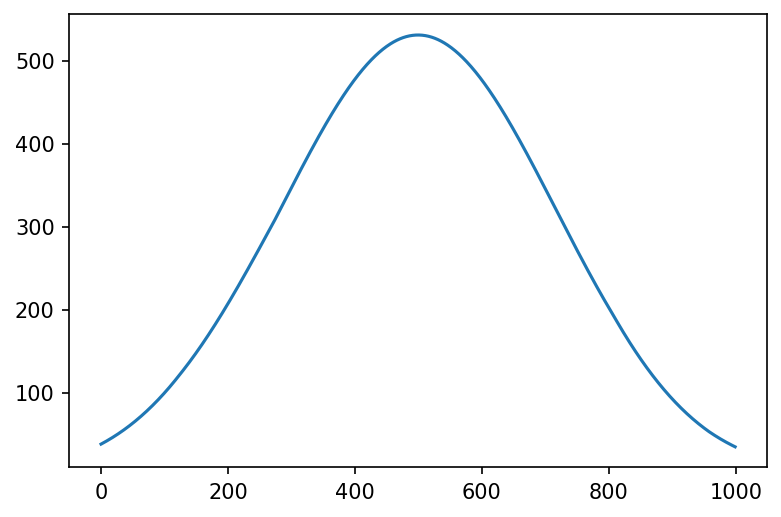

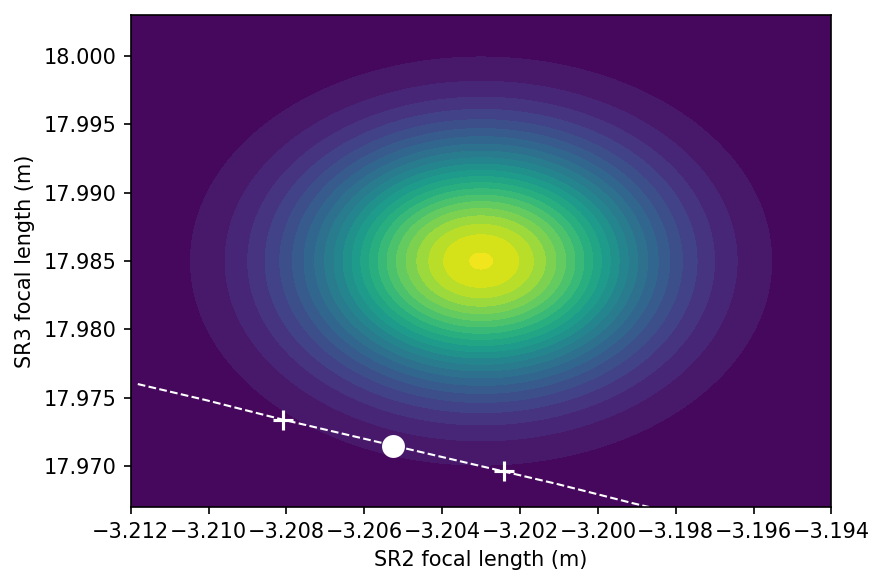

SR2 focal length = -3.2052565765765766 + 0.002841081081081054 - 0.0028279279279277425
SR3 focal length = 17.971504384384385 + -0.0018940540540555162 - -0.0018852852852830893


In [25]:
x_size = 1000
y_size = 1000

mu_x = -3.203
std_x = 0.003
x = np.linspace(mu_x - 3 * std_x, mu_x + 3 * std_x, x_size)
norm_pdf_x = 1/(std_x*np.sqrt(2*np.pi))*np.exp( -1/2 * ((x-mu_x)/std_x)**2)


mu_y = 17.985
std_y = 0.006
y = np.linspace(mu_y - 3 * std_y, mu_y + 3 * std_y, y_size)
norm_pdf_y = 1/(std_y*np.sqrt(2*np.pi))*np.exp( -1/2 * ((y-mu_y)/std_y)**2)

norm_pdf_xy = norm_pdf_y.reshape(y_size,1)*norm_pdf_x.reshape(1,x_size)

#shape of sr2_vals and sr3_vals is the same
len_interp = 1000
sr2_interp = np.linspace(min(sr2_vals), max(sr2_vals), len_interp)
sr3_interp = np.interp(sr2_interp,sr2_vals,sr3_vals)

prob_sr3_sr2 = []

for idx in range(0,len_interp):
    prob1 = 1/(std_x*np.sqrt(2*np.pi))*np.exp( -1/2 * ((sr2_interp[idx]-mu_x)/std_x)**2)
    prob2 = 1/(std_y*np.sqrt(2*np.pi))*np.exp( -1/2 * ((sr3_interp[idx]-mu_y)/std_y)**2)
    prob_sr3_sr2.append(prob1*prob2)

    
index_of_max = int(np.where(prob_sr3_sr2 == max(prob_sr3_sr2))[0])
index_of_std_upper = 0
index_of_std_lower = 0
best = 1e9

for idx,val in enumerate(prob_sr3_sr2):
    if(idx > index_of_max ):
        break
    else:
        attempt = 0.61*max(prob_sr3_sr2) - val 
        if(np.abs(attempt) < best):
            best = attempt
            index_of_std_lower = idx
    
best = 1e9

for idx,val in enumerate(prob_sr3_sr2):
    if(idx < index_of_max ):
        pass
    else:
        attempt = val - 0.61*max(prob_sr3_sr2)  
        if(np.abs(attempt) < best):
            best = attempt
            index_of_std_upper = idx
        


plt.figure(figsize = (6,4),dpi = 150)
plt.plot(prob_sr3_sr2)
plt.show()

plt.figure(figsize = (6,4),dpi = 150)
plt.contourf(x,y,norm_pdf_xy,levels = 25)
plt.plot(sr2_interp,sr3_interp,color = 'w',linestyle = '--', linewidth = 1)
plt.scatter(sr2_interp[index_of_max],sr3_interp[index_of_max],color = 'w',s = 100)
plt.scatter(sr2_interp[index_of_std_upper],sr3_interp[index_of_std_upper],color = 'w',marker = '+',s = 100)
plt.scatter(sr2_interp[index_of_std_lower],sr3_interp[index_of_std_lower],color = 'w',marker = '+',s = 100)
plt.xlabel('SR2 focal length (m)')
plt.ylabel('SR3 focal length (m)')
plt.tight_layout()
plt.savefig('sim_chapter_SR3_SR2_likely_values.png')
plt.savefig('sim_chapter_SR3_SR2_likely_values.eps')
plt.show()

sr2_likely = sr2_interp[index_of_max]
sr2_likely_plus = sr2_interp[index_of_std_upper] - sr2_interp[index_of_max]
sr2_likely_minus = sr2_interp[index_of_max] - sr2_interp[index_of_std_lower] 

sr3_likely = sr3_interp[index_of_max]
sr3_likely_plus = sr3_interp[index_of_std_upper] - sr3_interp[index_of_max]
sr3_likely_minus = sr3_interp[index_of_max] - sr3_interp[index_of_std_lower] 


print('SR2 focal length = {0} + {1} - {2}'.format(sr2_likely,sr2_likely_plus,sr2_likely_minus))
print('SR3 focal length = {0} + {1} - {2}'.format(sr3_likely,sr3_likely_plus,sr3_likely_minus))